# Part II: Vision Task - Image Classification with Convolutional Neural Networks

# 1. Install & Import All Libraries

In [4]:
#  Core Python 
import os, time, random, warnings
warnings.filterwarnings('ignore')

#  Numerical & Data 
import numpy as np
import pandas as pd
from PIL import Image

#  Visualisation 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

#  Machine Learning Utilities 
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

#  Deep Learning 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam, SGD

# Reproducibility 
SEED = 7
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f"TensorFlow  : {tf.__version__}")
print(f"Keras       : {keras.__version__}")
print(f"GPU devices : {tf.config.list_physical_devices('GPU')}")
print("  All libraries loaded successfully.")


TensorFlow  : 2.19.0
Keras       : 3.10.0
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
  All libraries loaded successfully.


# Dataset Path Configuration

In [5]:
# Dataset paths (Kaggle Fruits-360 structure) 
TRAIN_DIR = '/kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Training'
TEST_DIR  = '/kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Test'

#  Auto-discovery fallback 
if not os.path.exists(TRAIN_DIR):
    print("Default path not found – scanning /kaggle/input ")
    for root, dirs, _ in os.walk('/kaggle/input'):
        for d in dirs:
            full_path = os.path.join(root, d)
            if d == 'Training' and 'fruit' in full_path.lower():
                TRAIN_DIR = full_path
            if d == 'Test' and 'fruit' in full_path.lower():
                TEST_DIR = full_path

print(f"Train path : {TRAIN_DIR}  (exists={os.path.exists(TRAIN_DIR)})")
print(f"Test path  : {TEST_DIR}   (exists={os.path.exists(TEST_DIR)})")

#  Global Configuration 
IMG_SIZE       = (100, 100)   #
BATCH_SIZE     = 64
EPOCHS_BASE = 10
EPOCHS_DEEP = 15
EPOCHS_TL   = 10
VAL_SPLIT    = 0.20         

print(f"\nImage dimensions : {IMG_SIZE}")
print(f"Batch size       : {BATCH_SIZE}")
print(f"Base epochs      : {EPOCHS_BASE}")
print(f"Deep epochs      : {EPOCHS_DEEP}")


Train path : /kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Training  (exists=True)
Test path  : /kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Test   (exists=True)

Image dimensions : (100, 100)
Batch size       : 64
Base epochs      : 10
Deep epochs      : 15


# PART A – SECTION 1: Data Understanding, Analysis, Visualisation & Cleaning

# Dataset Overview

In [6]:
#  Gather per-class image counts 
train_classes = sorted(os.listdir(TRAIN_DIR))
test_classes  = sorted(os.listdir(TEST_DIR))

train_counts = {c: len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in train_classes}
test_counts  = {c: len(os.listdir(os.path.join(TEST_DIR,  c))) for c in test_classes}

total_train = sum(train_counts.values())
total_test  = sum(test_counts.values())
num_classes         = len(train_classes)

print("_" * 55)
print("  Fruits-360 Dataset Summary")
print("_" * 55)
print(f"  Classes              : {num_classes}")
print(f"  Training images      : {total_train:,}")
print(f"  Test images          : {total_test:,}")
print(f"  Grand total          : {total_train + total_test:,}")
print(f"  Image resolution     : 100 × 100 × 3 (RGB)")

# Build summary DataFrame
dist_df = pd.DataFrame({
    'Class': list(train_counts.keys()),
    'Train': list(train_counts.values()),
    'Test' : [test_counts.get(c, 0) for c in train_counts]
})
dist_df['Total'] = dist_df['Train'] + dist_df['Test']

print(f"\nTraining set statistics:")
print(f"  Min per class  : {dist_df['Train'].min()}")
print(f"  Max per class  : {dist_df['Train'].max()}")
print(f"  Mean per class : {dist_df['Train'].mean():.1f}")
print(f"  Std dev        : {dist_df['Train'].std():.1f}")
print(f"\nFirst 10 classes:")
print(dist_df.head(10).to_string(index=False))


_______________________________________________________
  Fruits-360 Dataset Summary
_______________________________________________________
  Classes              : 258
  Training images      : 135,313
  Test images          : 45,088
  Grand total          : 180,401
  Image resolution     : 100 × 100 × 3 (RGB)

Training set statistics:
  Min per class  : 144
  Max per class  : 984
  Mean per class : 524.5
  Std dev        : 168.6

First 10 classes:
    Class  Train  Test  Total
Almonds 1    232    77    309
 Apple 10    699   231    930
 Apple 11    430   142    572
 Apple 12    466   154    620
 Apple 13    699   235    934
 Apple 14    466   154    620
 Apple 17    610   201    811
 Apple 18    724   240    964
 Apple 19    729   241    970
 Apple 20    702   234    936


# Class Distribution Visualization

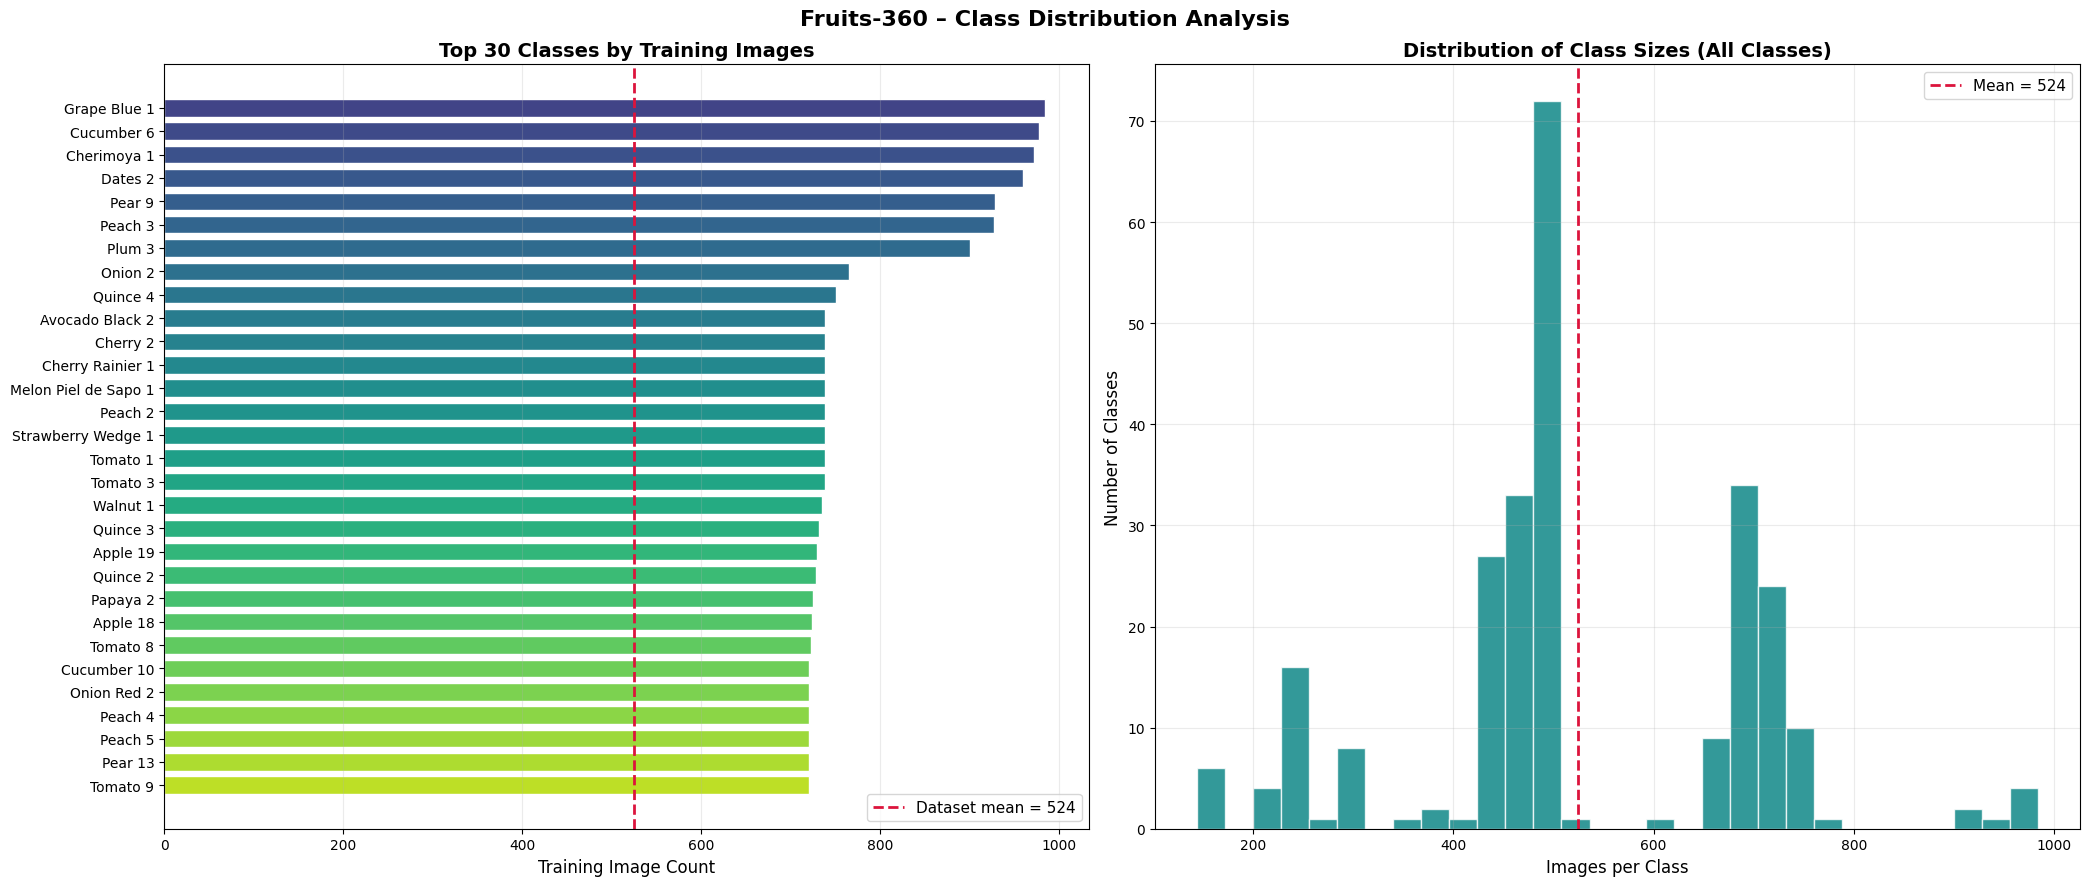

Saved → class_distribution.png


In [7]:
#  Visualise top-30 classes + overall frequency histogram 
top30 = dist_df.nlargest(30, 'Train')
mean_per_class = dist_df['Train'].mean()

fig, (ax_bar, ax_hist) = plt.subplots(1, 2, figsize=(21, 9))

#  Left: Horizontal bar chart for top 30 
palette = plt.cm.viridis(np.linspace(0.2, 0.9, len(top30)))
hbars = ax_bar.barh(top30['Class'], top30['Train'],
                    color=palette, edgecolor='white', height=0.75)
ax_bar.axvline(mean_per_class, color='crimson', linestyle='--', lw=2,
               label=f'Dataset mean = {mean_per_class:.0f}')
ax_bar.set_xlabel('Training Image Count', fontsize=12)
ax_bar.set_title('Top 30 Classes by Training Images', fontsize=14, fontweight='bold')
ax_bar.invert_yaxis()
ax_bar.legend(fontsize=11); ax_bar.grid(axis='x', alpha=0.25)

#  Right: Histogram of all class sizes 
ax_hist.hist(dist_df['Train'], bins=30, color='teal', edgecolor='white', alpha=0.80)
ax_hist.axvline(mean_per_class, color='crimson', linestyle='--', lw=2,
                label=f'Mean = {mean_per_class:.0f}')
ax_hist.set_xlabel('Images per Class', fontsize=12)
ax_hist.set_ylabel('Number of Classes', fontsize=12)
ax_hist.set_title('Distribution of Class Sizes (All Classes)', fontsize=14, fontweight='bold')
ax_hist.legend(fontsize=11); ax_hist.grid(alpha=0.25)

plt.suptitle('Fruits-360 – Class Distribution Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → class_distribution.png")


# Sample Images from Dataset

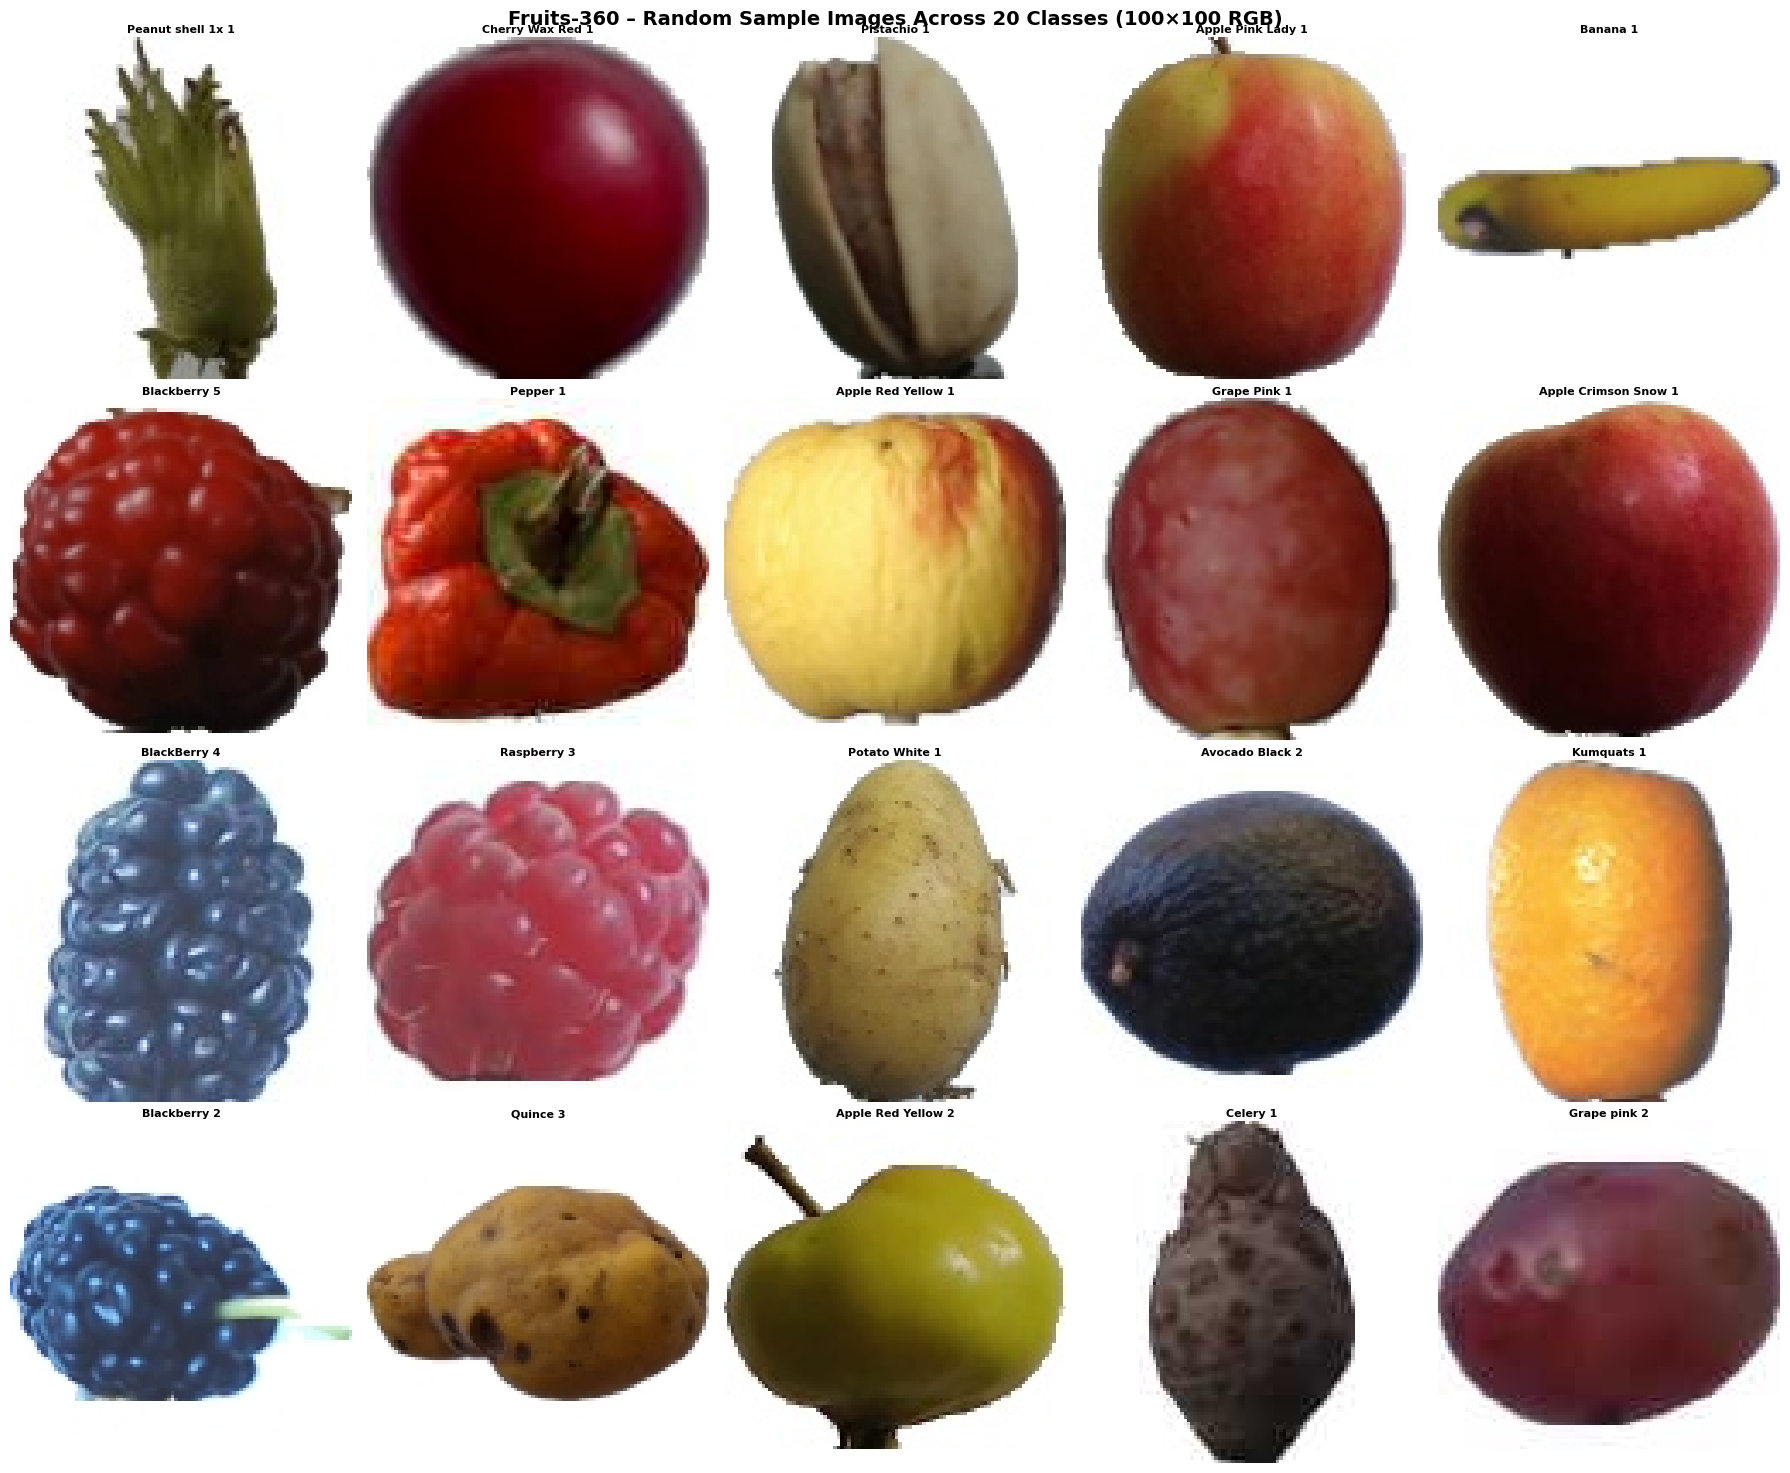

Saved → sample_images.png


In [8]:
# Display one random image from 20 different randomly chosen classes 
sample_classes = random.sample(train_classes, 20)

fig, axes = plt.subplots(4, 5, figsize=(18, 15))
axes = axes.ravel()

for idx, cls_name in enumerate(sample_classes):
    cls_dir   = os.path.join(TRAIN_DIR, cls_name)
    img_file = random.choice(os.listdir(cls_dir))
    img   = plt.imread(os.path.join(cls_dir, img_file))
    axes[idx].imshow(img)
    axes[idx].set_title(cls_name, fontsize=8, fontweight='bold', pad=3)
    axes[idx].axis('off')

plt.suptitle('Fruits-360 – Random Sample Images Across 20 Classes (100×100 RGB)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → sample_images.png")


# Pixel Intensity Analysis

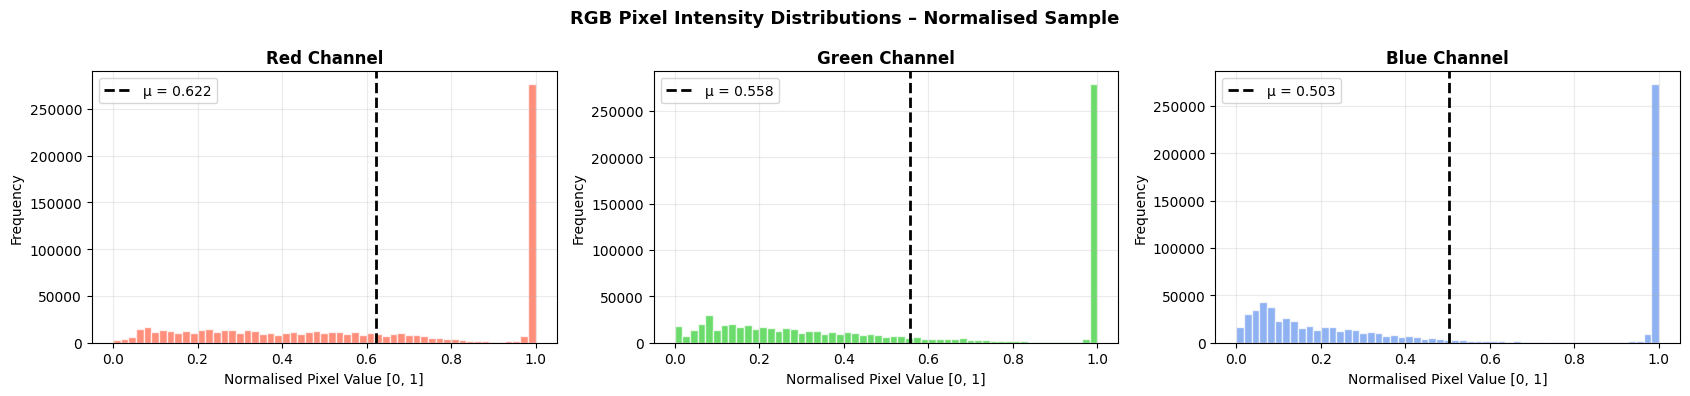

Channel means (R, G, B) : [0.622  0.5576 0.5031]
Channel stds  (R, G, B) : [0.3442 0.3813 0.4105]
Note: high frequency at ~1.0 confirms Fruits-360 white background (pixel=255/255=1.0)


In [9]:
#  Sample images from 15 classes; analyse RGB channel distributions 
pixel_samples = []
for cls_name in random.sample(train_classes, 15):
    cls_dir = os.path.join(TRAIN_DIR, cls_name)
    all_files = os.listdir(cls_dir)
    for fname in random.sample(all_files, min(5, len(all_files))):
        arr = np.array(Image.open(os.path.join(cls_dir, fname)).resize(IMG_SIZE)) / 255.0
        if arr.ndim == 3 and arr.shape[-1] == 3:
            pixel_samples.append(arr)

pixel_arr = np.stack(pixel_samples)   # (N, 100, 100, 3)

channels  = ['Red', 'Green', 'Blue']
colors = ['tomato', 'limegreen', 'cornflowerblue']

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ch_idx, (ax, ch_name, ch_col) in enumerate(zip(axes, channels, colors)):
    channel_vals = pixel_arr[..., ch_idx].ravel()
    ch_mean_val   = channel_vals.mean()
    ax.hist(channel_vals, bins=55, color=ch_col, alpha=0.72, edgecolor='white')
    ax.axvline(ch_mean_val, color='black', linestyle='--', lw=2,
               label=f'μ = {ch_mean_val:.3f}')
    ax.set_title(f'{ch_name} Channel', fontsize=12, fontweight='bold')
    ax.set_xlabel('Normalised Pixel Value [0, 1]')
    ax.set_ylabel('Frequency')
    ax.legend(); ax.grid(alpha=0.25)

plt.suptitle('RGB Pixel Intensity Distributions – Normalised Sample',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pixel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

mean_rgb = pixel_arr.mean(axis=(0, 1, 2))
std_rgb  = pixel_arr.std(axis=(0, 1, 2))
print(f"Channel means (R, G, B) : {mean_rgb.round(4)}")
print(f"Channel stds  (R, G, B) : {std_rgb.round(4)}")
print("Note: high frequency at ~1.0 confirms Fruits-360 white background (pixel=255/255=1.0)")


# Data Generators: Preprocessing & Augmentation

In [10]:
#  Training generator with augmentation and 80/20 split 
train_datagen = ImageDataGenerator(
    rescale            = 1. / 255,
    rotation_range     = 25,
    width_shift_range  = 0.12,
    height_shift_range = 0.12,
    shear_range        = 0.08,
    zoom_range         = 0.18,
    horizontal_flip    = True,
    validation_split   = VAL_SPLIT
)

# Test generator 
test_datagen = ImageDataGenerator(rescale=1. / 255)

#  Instantiate generators 
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=SEED
)
val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=SEED
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

NUM_CLASSES    = train_gen.num_classes
CLASS_LABELS  = list(train_gen.class_indices.keys())
INPUT_SHAPE  = (IMG_SIZE[0], IMG_SIZE[1], 3)

print(f"  Training samples   : {train_gen.samples:,}")
print(f"  Validation samples : {val_gen.samples:,}")
print(f"  Test samples       : {test_gen.samples:,}")
print(f"  Total classes      : {NUM_CLASSES}")
print(f"  Input tensor shape : {INPUT_SHAPE}")


Found 108338 images belonging to 258 classes.
Found 26975 images belonging to 258 classes.
Found 45088 images belonging to 258 classes.
  Training samples   : 108,338
  Validation samples : 26,975
  Test samples       : 45,088
  Total classes      : 258
  Input tensor shape : (100, 100, 3)


# Visualise Augmented Images

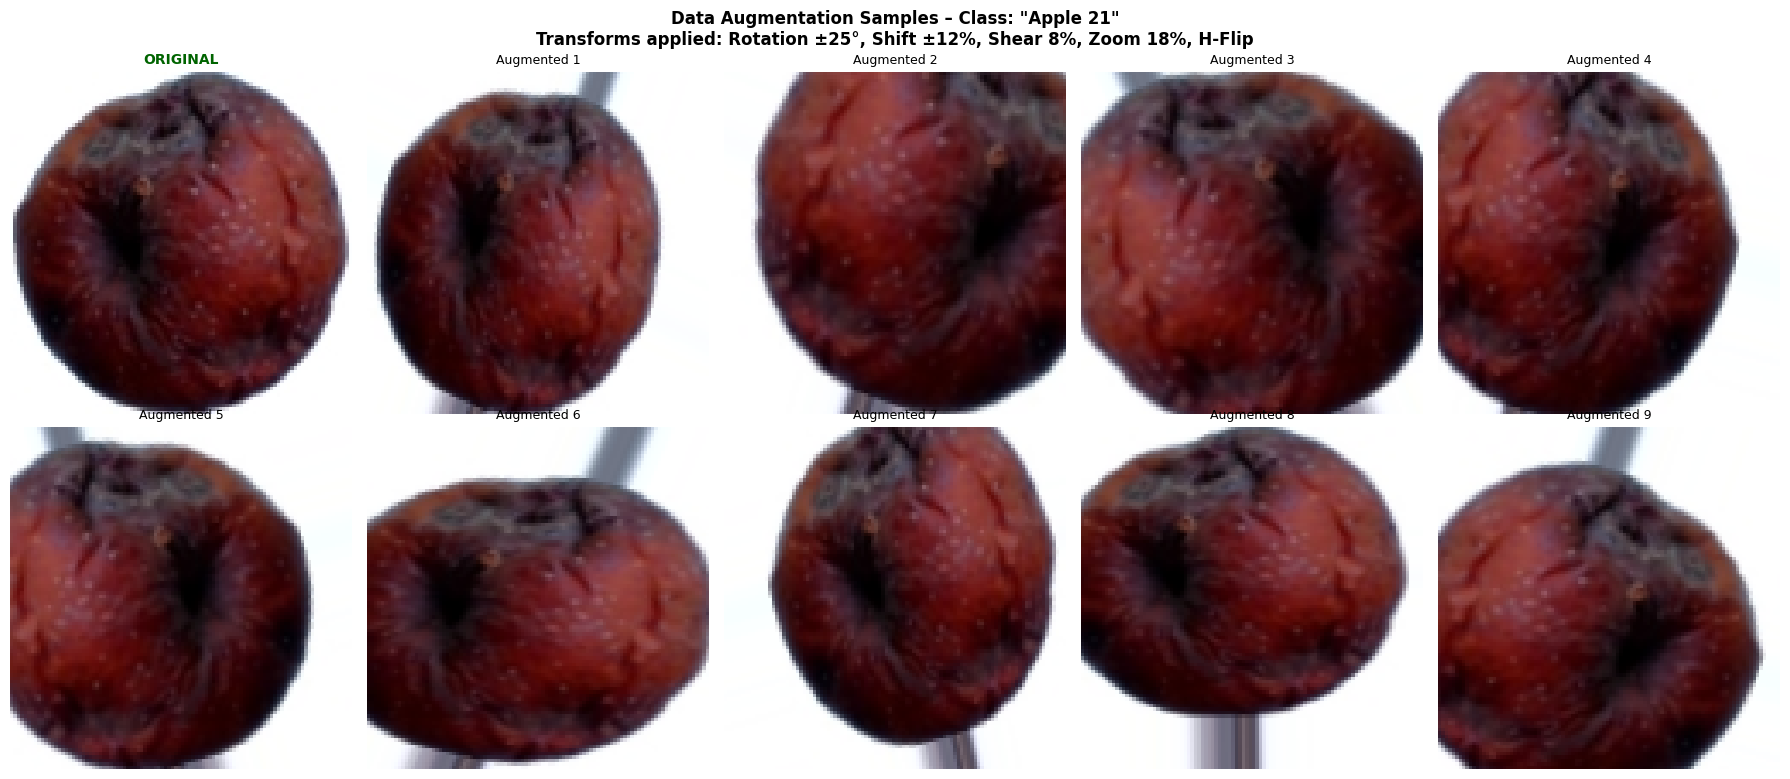

Saved augmentation_examples.png


In [11]:
#  Pick one class, load one original image, apply augmentations 
sample_cls   = train_classes[10]
sample_cls_dir   = os.path.join(TRAIN_DIR, sample_cls)
sample_fname = os.listdir(sample_cls_dir)[0]
original   = np.array(Image.open(os.path.join(sample_cls_dir, sample_fname)).resize(IMG_SIZE))

aug_gen_vis = ImageDataGenerator(
    rotation_range=25, width_shift_range=0.12, height_shift_range=0.12,
    shear_range=0.08, zoom_range=0.18, horizontal_flip=True
)
aug_iter = aug_gen_vis.flow(original[np.newaxis, ...], batch_size=1, seed=SEED)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.ravel()

axes[0].imshow(original)
axes[0].set_title('ORIGINAL', fontweight='bold', color='darkgreen', fontsize=10)
axes[0].axis('off')

for j in range(1, 10):
    aug_img = next(aug_iter)[0].astype(np.uint8)
    axes[j].imshow(aug_img)
    axes[j].set_title(f'Augmented {j}', fontsize=9)
    axes[j].axis('off')

plt.suptitle(
    f'Data Augmentation Samples – Class: "{sample_cls}"\n'
    f'Transforms applied: Rotation ±25°, Shift ±12%, Shear 8%, Zoom 18%, H-Flip',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved augmentation_examples.png")


# PART A – SECTION 2: Baseline CNN Model

# Build Baseline CNN Model

In [14]:
# ── Baseline CNN: 3 Conv blocks + 3 FC layers ────────────────────────────────
# Architecture highlights:
#   Conv1 : 32 filters, 3×3 kernel, ReLU → MaxPool 2×2
#   Conv2 : 64 filters, 3×3 kernel, ReLU → MaxPool 2×2
#   Conv3 : 128 filters, 3×3 kernel, ReLU → MaxPool 2×2
#   FC1   : 256 units, ReLU, Dropout 0.4
#   FC2   : 128 units, ReLU, Dropout 0.3
#   FC3   : 64 units, ReLU
#   Output: NUM_CLASSES units, Softmax

def build_baseline_cnn(shape, num_classes):
    model = models.Sequential(name='Baseline_CNN')

    #  Convolutional Block 1 
    model.add(layers.Conv2D(32, kernel_size=(3, 3), activation='relu',
                          padding='same', input_shape=shape, name='ConvBlock1'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2), name='Pool1'))

    #  Convolutional Block 2 
    model.add(layers.Conv2D(64, kernel_size=(3, 3), activation='relu',
                          padding='same', name='ConvBlock2'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2), name='Pool2'))

    #  Convolutional Block 3 
    model.add(layers.Conv2D(128, kernel_size=(3, 3), activation='relu',
                          padding='same', name='ConvBlock3'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2), name='Pool3'))

    # Classifier Head 
    model.add(layers.Flatten(name='Flatten'))
    model.add(layers.Dense(256, activation='relu', name='FC1'))
    model.add(layers.Dropout(0.40, name='Drop_FC1'))
    model.add(layers.Dense(128, activation='relu', name='FC2'))
    model.add(layers.Dropout(0.30, name='Drop_FC2'))
    model.add(layers.Dense(64, activation='relu', name='FC3'))
    model.add(layers.Dense(num_classes, activation='softmax', name='Output'))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline_model = build_baseline_cnn(INPUT_SHAPE, NUM_CLASSES)
baseline_model.summary()


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ConvBlock1 (Conv2D)             │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ConvBlock2 (Conv2D)             │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ConvBlock3 (Conv2D)             │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool3 (MaxPooling2D)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC1 (Dense)                     │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop_FC1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop_FC2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC3 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 258)            │        16,770 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,870,018 (18.58 MB)

 Trainable params: 4,870,018 (18.58 MB)

 Non-trainable params: 0 (0.00 B)

# Train Baseline CNN

In [15]:
callbacks_base = [
    EarlyStopping(monitor='val_accuracy', patience=4,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, min_lr=1e-7, verbose=1)
]

print(" Training Baseline CNN ...")
print(f"  Epochs: {EPOCHS_BASE}  |  Batch: {BATCH_SIZE}  |  Optimiser: Adam lr=1e-3")
t_start = time.time()

history_base = baseline_model.fit(
    train_gen,
    epochs=EPOCHS_BASE,
    validation_data=val_gen,
    callbacks=callbacks_base,
    verbose=1
)

base_train_time = time.time() - t_start
print(f"\n Baseline CNN trained in {base_train_time / 60:.2f} minutes")


 Training Baseline CNN ...
  Epochs: 10  |  Batch: 64  |  Optimiser: Adam lr=1e-3
Epoch 1/10
1693/1693 ━━━━━━━━━━━━━━━━━━━━ 1213s 714ms/step - accuracy: 0.0995 - loss: 4.0578 - val_accuracy: 0.6120 - val_loss: 1.3056 - learning_rate: 0.0010
Epoch 2/10
1693/1693 ━━━━━━━━━━━━━━━━━━━━ 535s 316ms/step - accuracy: 0.4915 - loss: 1.5682 - val_accuracy: 0.7507 - val_loss: 0.7810 - learning_rate: 0.0010
Epoch 3/10
1693/1693 ━━━━━━━━━━━━━━━━━━━━ 524s 310ms/step - accuracy: 0.6484 - loss: 1.0561 - val_accuracy: 0.8198 - val_loss: 0.5320 - learning_rate: 0.0010
Epoch 4/10
1693/1693 ━━━━━━━━━━━━━━━━━━━━ 534s 316ms/step - accuracy: 0.7213 - loss: 0.8173 - val_accuracy: 0.8598 - val_loss: 0.4404 - learning_rate: 0.0010
Epoch 5/10
1693/1693 ━━━━━━━━━━━━━━━━━━━━ 521s 308ms/step - accuracy: 0.7658 - loss: 0.6933 - val_accuracy: 0.8776 - val_loss: 0.3602 - learning_rate: 0.0010
Epoch 6/10
1693/1693 ━━━━━━━━━━━━━━━━━━━━ 512s 303ms/step - accuracy: 0.7950 - loss: 0.6021 - val_accuracy: 0.8943 - val_loss: 

# Baseline Training Curves

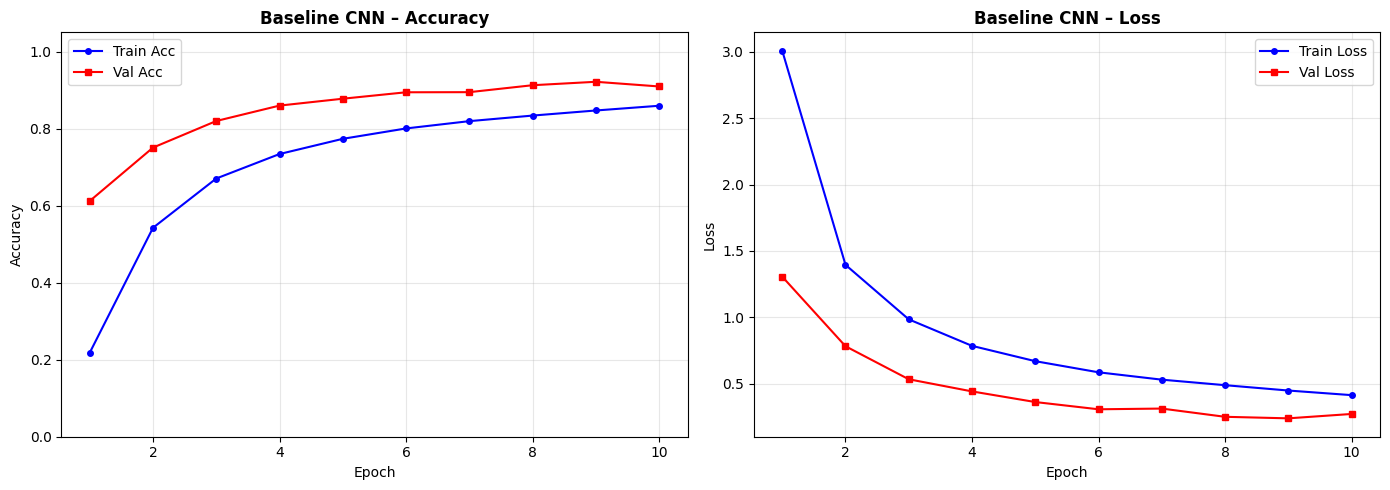

Saved → baseline_training_curves.png
Best validation accuracy : 0.9216 at epoch 9


In [16]:
def plot_history(hist, title, fname):
    """Render accuracy and loss curves side by side."""
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))

    ep = range(1, len(hist.history['accuracy']) + 1)

    a1.plot(ep, hist.history['accuracy'],     'b-o', ms=4, lw=1.5, label='Train Acc')
    a1.plot(ep, hist.history['val_accuracy'], 'r-s', ms=4, lw=1.5, label='Val Acc')
    a1.set_title(f'{title} – Accuracy', fontsize=12, fontweight='bold')
    a1.set_xlabel('Epoch'); a1.set_ylabel('Accuracy')
    a1.legend(); a1.grid(alpha=0.3); a1.set_ylim(0, 1.05)

    a2.plot(ep, hist.history['loss'],     'b-o', ms=4, lw=1.5, label='Train Loss')
    a2.plot(ep, hist.history['val_loss'], 'r-s', ms=4, lw=1.5, label='Val Loss')
    a2.set_title(f'{title} – Loss', fontsize=12, fontweight='bold')
    a2.set_xlabel('Epoch'); a2.set_ylabel('Loss')
    a2.legend(); a2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {fname}")

plot_history(history_base, 'Baseline CNN', 'baseline_training_curves.png')

best_val_acc = max(history_base.history['val_accuracy'])
best_epoch  = history_base.history['val_accuracy'].index(best_val_acc) + 1
print(f"Best validation accuracy : {best_val_acc:.4f} at epoch {best_epoch}")


# Evaluate Baseline CNN

In [17]:
def evaluate_model(model, gen, label):
    """Compute and print accuracy, precision, recall, F1 on generator data."""
    gen.reset()
    y_pred_prob  = model.predict(gen, verbose=1)
    y_pred  = np.argmax(y_pred_prob, axis=1)
    y_true = gen.classes

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f} %)")
    print(f"  Precision : {prec:.4f}  (weighted)")
    print(f"  Recall    : {rec:.4f}  (weighted)")
    print(f"  F1-Score  : {f1:.4f}  (weighted)")

    return dict(label=label, acc=acc, prec=prec, rec=rec, f1=f1,
                y_pred=y_pred, y_true=y_true)

base_metrics = evaluate_model(baseline_model, test_gen, 'Baseline CNN – Test Set')

print("\nDetailed classification report:")
print(classification_report(base_metrics['y_true'], base_metrics['y_pred'],
                             target_names=CLASS_LABELS, zero_division=0))


705/705 ━━━━━━━━━━━━━━━━━━━━ 339s 481ms/step

  Baseline CNN – Test Set
  Accuracy  : 0.9321  (93.21 %)
  Precision : 0.9374  (weighted)
  Recall    : 0.9321  (weighted)
  F1-Score  : 0.9265  (weighted)

Detailed classification report:
                        precision    recall  f1-score   support

             Almonds 1       1.00      0.95      0.97        77
              Apple 10       1.00      0.95      0.97       231
              Apple 11       1.00      1.00      1.00       142
              Apple 12       1.00      0.89      0.94       154
              Apple 13       0.97      1.00      0.99       235
              Apple 14       1.00      1.00      1.00       154
              Apple 17       1.00      1.00      1.00       201
              Apple 18       1.00      1.00      1.00       240
              Apple 19       0.97      1.00      0.99       241
              Apple 20       1.00      1.00      1.00       234
              Apple 21       0.98      1.00      0.99      

# Confusion Matrix (Baseline CNN)

Saved → baseline_cm.png


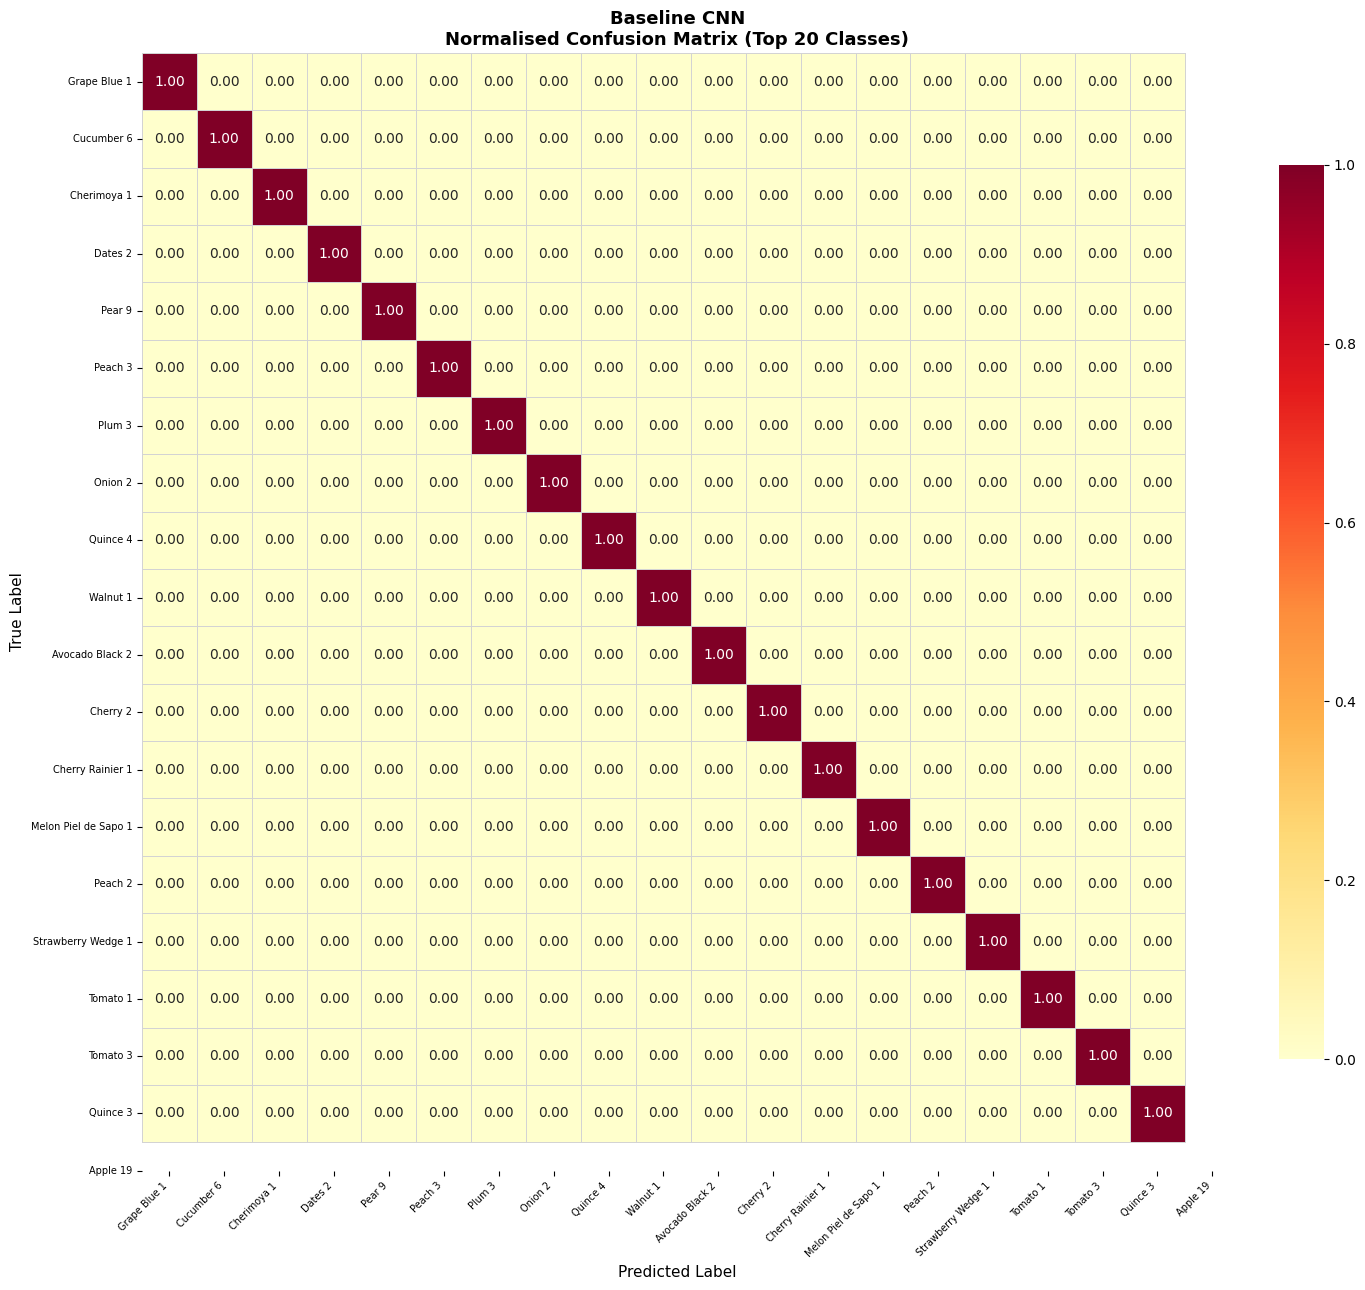

In [18]:
def plot_confusion_matrix_top(y_true, y_pred, names, title, top_n=20, save=None):
    """Normalised confusion matrix for the top_n most frequent classes."""
    from collections import Counter
    top_cls_ids = [i for i, _ in Counter(y_true).most_common(top_n)]
    keep = np.isin(y_true, top_cls_ids)
    yt, yp = y_true[keep], y_pred[keep]
    id2new = {old: new for new, old in enumerate(top_cls_ids)}
    yt_r = np.array([id2new[v] for v in yt])
    yp_r = np.array([id2new.get(v, -1) for v in yp])
    valid = yp_r >= 0
    yt_r, yp_r = yt_r[valid], yp_r[valid]
    lbl_names = [names[i] for i in top_cls_ids]
    cm = confusion_matrix(yt_r, yp_r)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(15, 13))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=lbl_names, yticklabels=lbl_names,
                ax=ax, linewidths=0.4, linecolor='lightgray',
                cbar_kws={'shrink': 0.8})
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_title(f'{title}\nNormalised Confusion Matrix (Top {top_n} Classes)',
                 fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches='tight')
        print(f"Saved → {save}")
    plt.show()

# Baseline CNN ← ONLY THIS CALL, delete the one above with save_name
plot_confusion_matrix_top(base_metrics['y_true'], base_metrics['y_pred'],
                      CLASS_LABELS, 'Baseline CNN', top_n=20,
                      save='baseline_cm.png')

# Inference on Sample Test Images (Baseline CNN)

Saved → baseline_inference.png


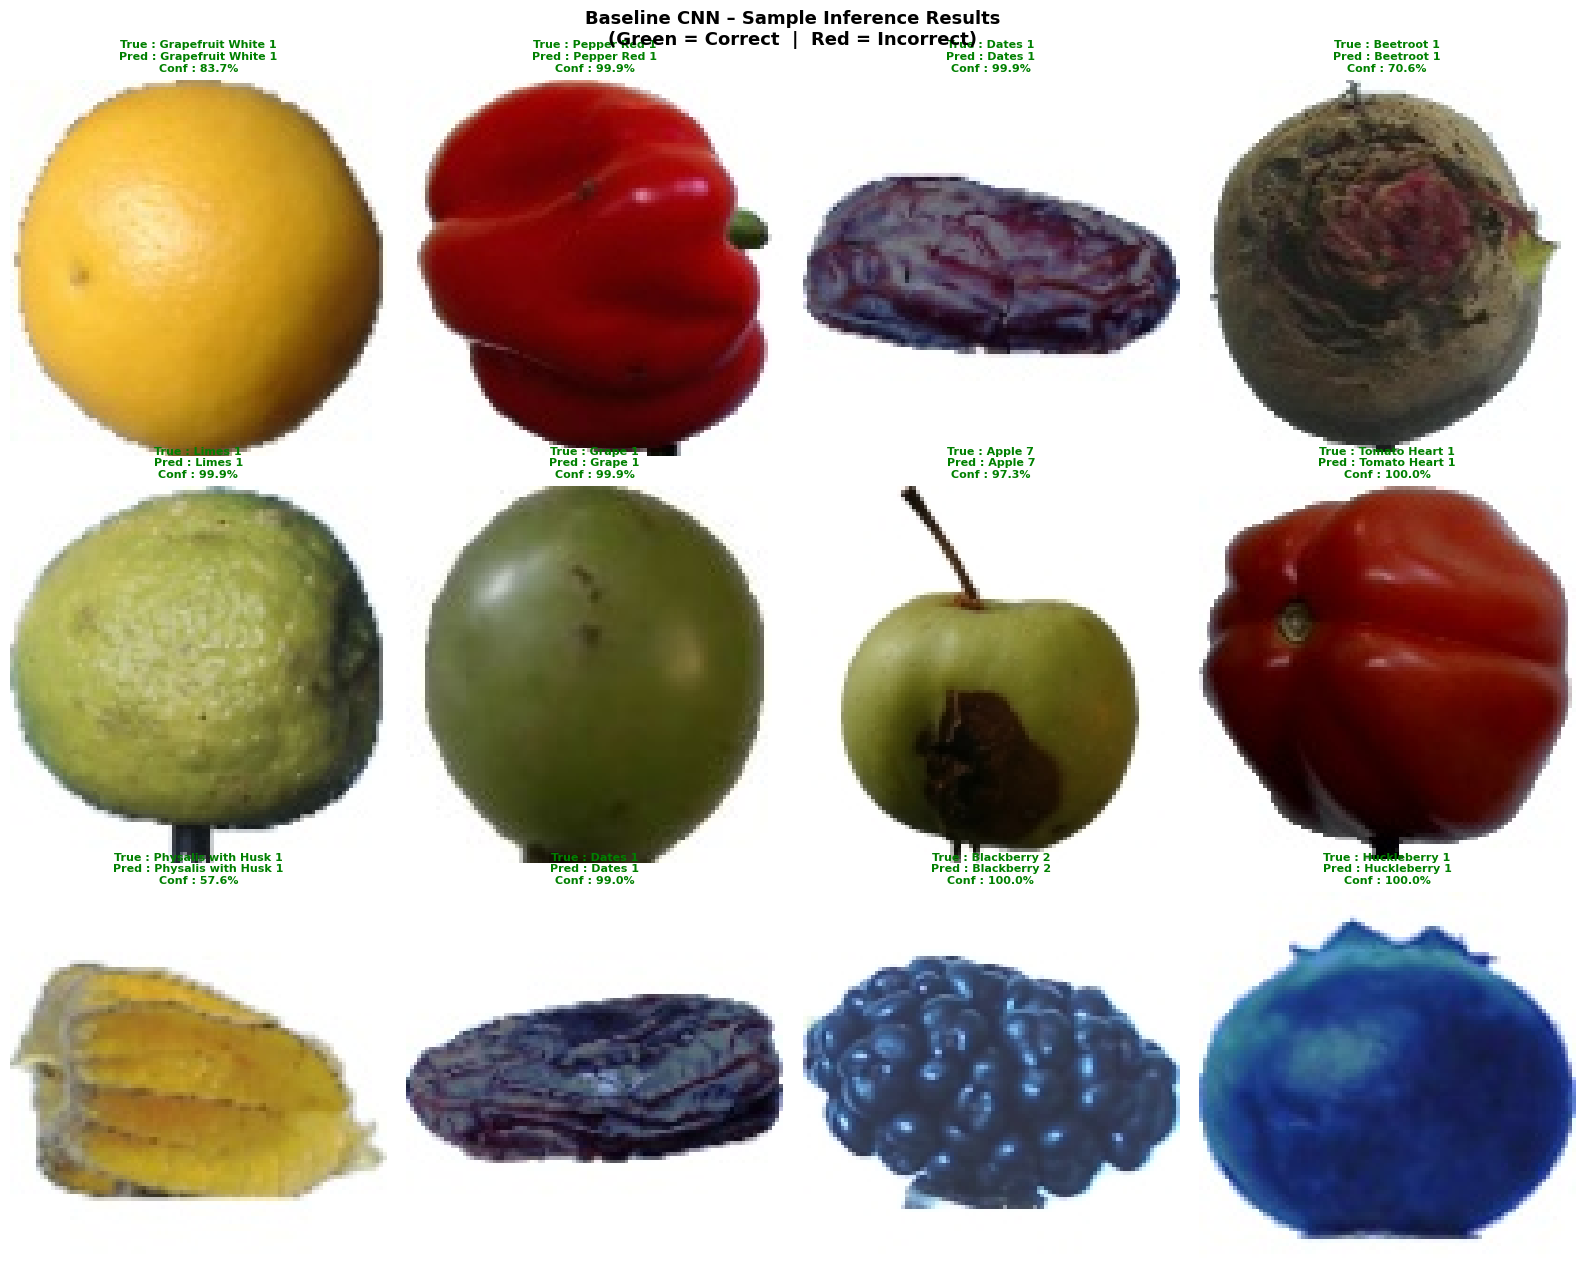

In [19]:
def show_inference(model, test_dir, cls_names, title, n_imgs=12, save=None):
    """Run inference on random test images and display predictions."""
    all_cls = sorted(os.listdir(test_dir))
    imgs, true_names = [], []

    random.seed(SEED + 1)
    for _ in range(n_imgs):
        c = random.choice(all_cls)
        c_dir = os.path.join(test_dir, c)
        f = random.choice(os.listdir(c_dir))
        arr = np.array(Image.open(os.path.join(c_dir, f)).resize(IMG_SIZE)) / 255.0
        imgs.append(arr); true_names.append(c)

    batch_input = np.array(imgs)
    pred_probs  = model.predict(batch_input, verbose=0)
    pred_ids    = np.argmax(pred_probs, axis=1)
    pred_names  = [cls_names[i] for i in pred_ids]
    confidences = [pred_probs[i, pred_ids[i]] * 100 for i in range(n_imgs)]

    fig, axes = plt.subplots(3, 4, figsize=(16, 13))
    axes = axes.ravel()

    for k in range(n_imgs):
        axes[k].imshow(imgs[k])
        ok     = pred_names[k] == true_names[k]
        colour = 'green' if ok else 'crimson'
        axes[k].set_title(
            f"True : {true_names[k]}\nPred : {pred_names[k]}\nConf : {confidences[k]:.1f}%",
            fontsize=8, color=colour, fontweight='bold'
        )
        axes[k].axis('off')

    plt.suptitle(f'{title} – Sample Inference Results\n'
                 f'(Green = Correct  |  Red = Incorrect)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches='tight')
        print(f"Saved → {save}")
    plt.show()

show_inference(baseline_model, TEST_DIR, CLASS_LABELS,
                  'Baseline CNN', save='baseline_inference.png')


# PART A – SECTION 3: Deeper Architecture with Regularisation Layer

# Build Deeper CNN Model

In [20]:
def build_deeper_cnn(shape, num_classes, opt_name='adam'):
    model = models.Sequential(name=f'Deeper_CNN_{opt_name.upper()}')
    
    def conv_bn_block(filters, pool=True, drop=0.25, input_shape=None):
        if input_shape:
            model.add(layers.Conv2D(filters, (3, 3), activation='relu', 
                                   padding='same', input_shape=input_shape))
        else:
            model.add(layers.Conv2D(filters, (3, 3), activation='relu', padding='same'))
        model.add(layers.BatchNormalization())
        if pool:
            model.add(layers.MaxPooling2D((2, 2)))
        model.add(layers.Dropout(drop))

    conv_bn_block(32,  pool=True, input_shape=shape)  # Block 1 
    conv_bn_block(64,  pool=True)    # Block 2
    conv_bn_block(128, pool=True)    # Block 3
    conv_bn_block(256, pool=False)   # Block 4
    conv_bn_block(256, pool=True)    # Block 5
    conv_bn_block(256, pool=False)   # Block 6
    conv_bn_block(512, pool=False)   # Block 7
    conv_bn_block(512, pool=True)    # Block 8

    model.add(layers.GlobalAveragePooling2D(name='GAP'))
    model.add(layers.Dense(512, activation='relu', name='Deep_FC1'))
    model.add(layers.Dropout(0.50, name='Deep_Drop1'))
    model.add(layers.Dense(256, activation='relu', name='Deep_FC2'))
    model.add(layers.Dropout(0.40, name='Deep_Drop2'))
    model.add(layers.Dense(num_classes, activation='softmax', name='Output'))

    if opt_name == 'adam':
        opt = Adam(learning_rate=0.001)
    else:
        opt = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

deeper_model_adam = build_deeper_cnn(INPUT_SHAPE, NUM_CLASSES, 'adam')
deeper_model_adam.summary()

Model: "Deeper_CNN_ADAM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 6, 6, 256)      │             

 Total params: 5,576,898 (21.27 MB)

 Trainable params: 5,572,866 (21.26 MB)

 Non-trainable params: 4,032 (15.75 KB)

# Train Deeper CNN (Adam Optimizer)

In [21]:
callbacks_deep = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1)
]

print(" Training Deeper CNN with Adam ...")
print(f"  Epochs: {EPOCHS_DEEP}  |  Batch: {BATCH_SIZE}  |  Optimiser: Adam lr=1e-3")
t_start = time.time()

history_deep_adam = deeper_model_adam.fit(
    train_gen, epochs=EPOCHS_DEEP,
    validation_data=val_gen,
    callbacks=callbacks_deep, verbose=1
)

deep_adam_time = time.time() - t_start
print(f"\n Deeper CNN (Adam) trained in {deep_adam_time / 60:.2f} minutes")


 Training Deeper CNN with Adam ...
  Epochs: 15  |  Batch: 64  |  Optimiser: Adam lr=1e-3
Epoch 1/15
1693/1693 ━━━━━━━━━━━━━━━━━━━━ 647s 370ms/step - accuracy: 0.1742 - loss: 3.5696 - val_accuracy: 0.2314 - val_loss: 3.4178 - learning_rate: 0.0010
Epoch 2/15
1693/1693 ━━━━━━━━━━━━━━━━━━━━ 604s 357ms/step - accuracy: 0.5797 - loss: 1.2978 - val_accuracy: 0.7043 - val_loss: 0.8646 - learning_rate: 0.0010
Epoch 3/15
1693/1693 ━━━━━━━━━━━━━━━━━━━━ 562s 332ms/step - accuracy: 0.7141 - loss: 0.8553 - val_accuracy: 0.7998 - val_loss: 0.6044 - learning_rate: 0.0010
Epoch 4/15
1693/1693 ━━━━━━━━━━━━━━━━━━━━ 542s 320ms/step - accuracy: 0.7848 - loss: 0.6343 - val_accuracy: 0.7618 - val_loss: 0.7880 - learning_rate: 0.0010
Epoch 5/15
1693/1693 ━━━━━━━━━━━━━━━━━━━━ 546s 322ms/step - accuracy: 0.8305 - loss: 0.4976 - val_accuracy: 0.8200 - val_loss: 0.5514 - learning_rate: 0.0010
Epoch 6/15
1693/1693 ━━━━━━━━━━━━━━━━━━━━ 548s 324ms/step - accuracy: 0.8631 - loss: 0.4017 - val_accuracy: 0.7956 - val

# Train Deeper CNN (SGD Optimizer)

In [24]:
deeper_model_sgd = build_deeper_cnn(INPUT_SHAPE, NUM_CLASSES, 'sgd')

print(" Training Deeper CNN with SGD ...")
print(f"  Epochs: {EPOCHS_DEEP}  |  Batch: {BATCH_SIZE}  |  Optimiser: SGD lr=0.01, momentum=0.9, Nesterov")

t_start = time.time()

history_deep_sgd = deeper_model_sgd.fit(
    train_gen,
    epochs=EPOCHS_DEEP,
    validation_data=val_gen,
    callbacks=callbacks_deep,
    steps_per_epoch=1000,
    validation_steps=200,
    verbose=1
)

deep_sgd_time = time.time() - t_start

print(f"\n Deeper CNN (SGD) trained in {deep_sgd_time / 60:.2f} minutes")

 Training Deeper CNN with SGD ...
  Epochs: 15  |  Batch: 64  |  Optimiser: SGD lr=0.01, momentum=0.9, Nesterov
Epoch 1/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 340s 326ms/step - accuracy: 0.1282 - loss: 4.0564 - val_accuracy: 0.0861 - val_loss: 5.4758 - learning_rate: 0.0100
Epoch 2/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 255s 255ms/step - accuracy: 0.4463 - loss: 1.7765 - val_accuracy: 0.1566 - val_loss: 5.3912 - learning_rate: 0.0100
Epoch 3/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 323s 323ms/step - accuracy: 0.5563 - loss: 1.3792 - val_accuracy: 0.3435 - val_loss: 2.5275 - learning_rate: 0.0100
Epoch 4/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 231s 231ms/step - accuracy: 0.6533 - loss: 1.0621 - val_accuracy: 0.3602 - val_loss: 2.5823 - learning_rate: 0.0100
Epoch 5/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 320s 320ms/step - accuracy: 0.7005 - loss: 0.9084 - val_accuracy: 0.5012 - val_loss: 1.8452 - learning_rate: 0.0100
Epoch 6/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 260s 260ms/step - accuracy: 0.7546 - loss: 0.7265 - val_

# Evaluate Both Deeper Models

705/705 ━━━━━━━━━━━━━━━━━━━━ 137s 193ms/step

  Deeper CNN (Adam)
  Accuracy  : 0.9535  (95.35 %)
  Precision : 0.9604  (weighted)
  Recall    : 0.9535  (weighted)
  F1-Score  : 0.9521  (weighted)
705/705 ━━━━━━━━━━━━━━━━━━━━ 54s 75ms/step

  Deeper CNN (SGD)
  Accuracy  : 0.8999  (89.99 %)
  Precision : 0.9092  (weighted)
  Recall    : 0.8999  (weighted)
  F1-Score  : 0.8950  (weighted)
Saved → deeper_adam_cm.png


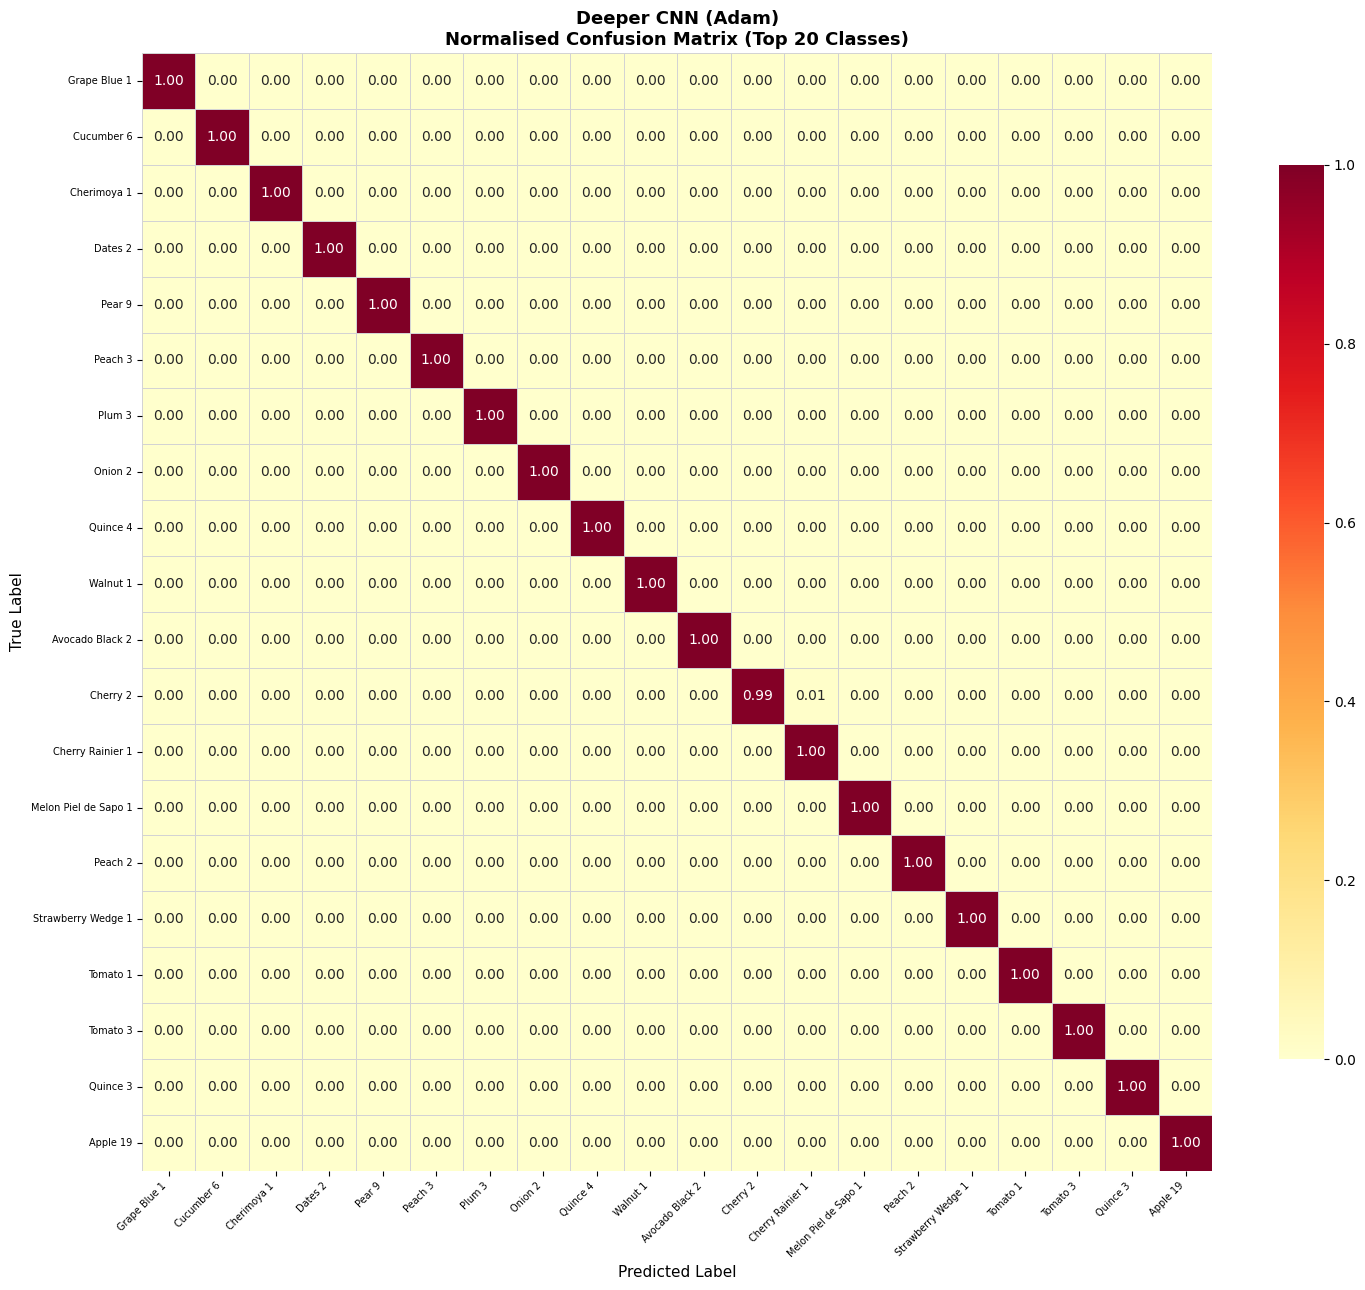

Saved → deeper_sgd_cm.png


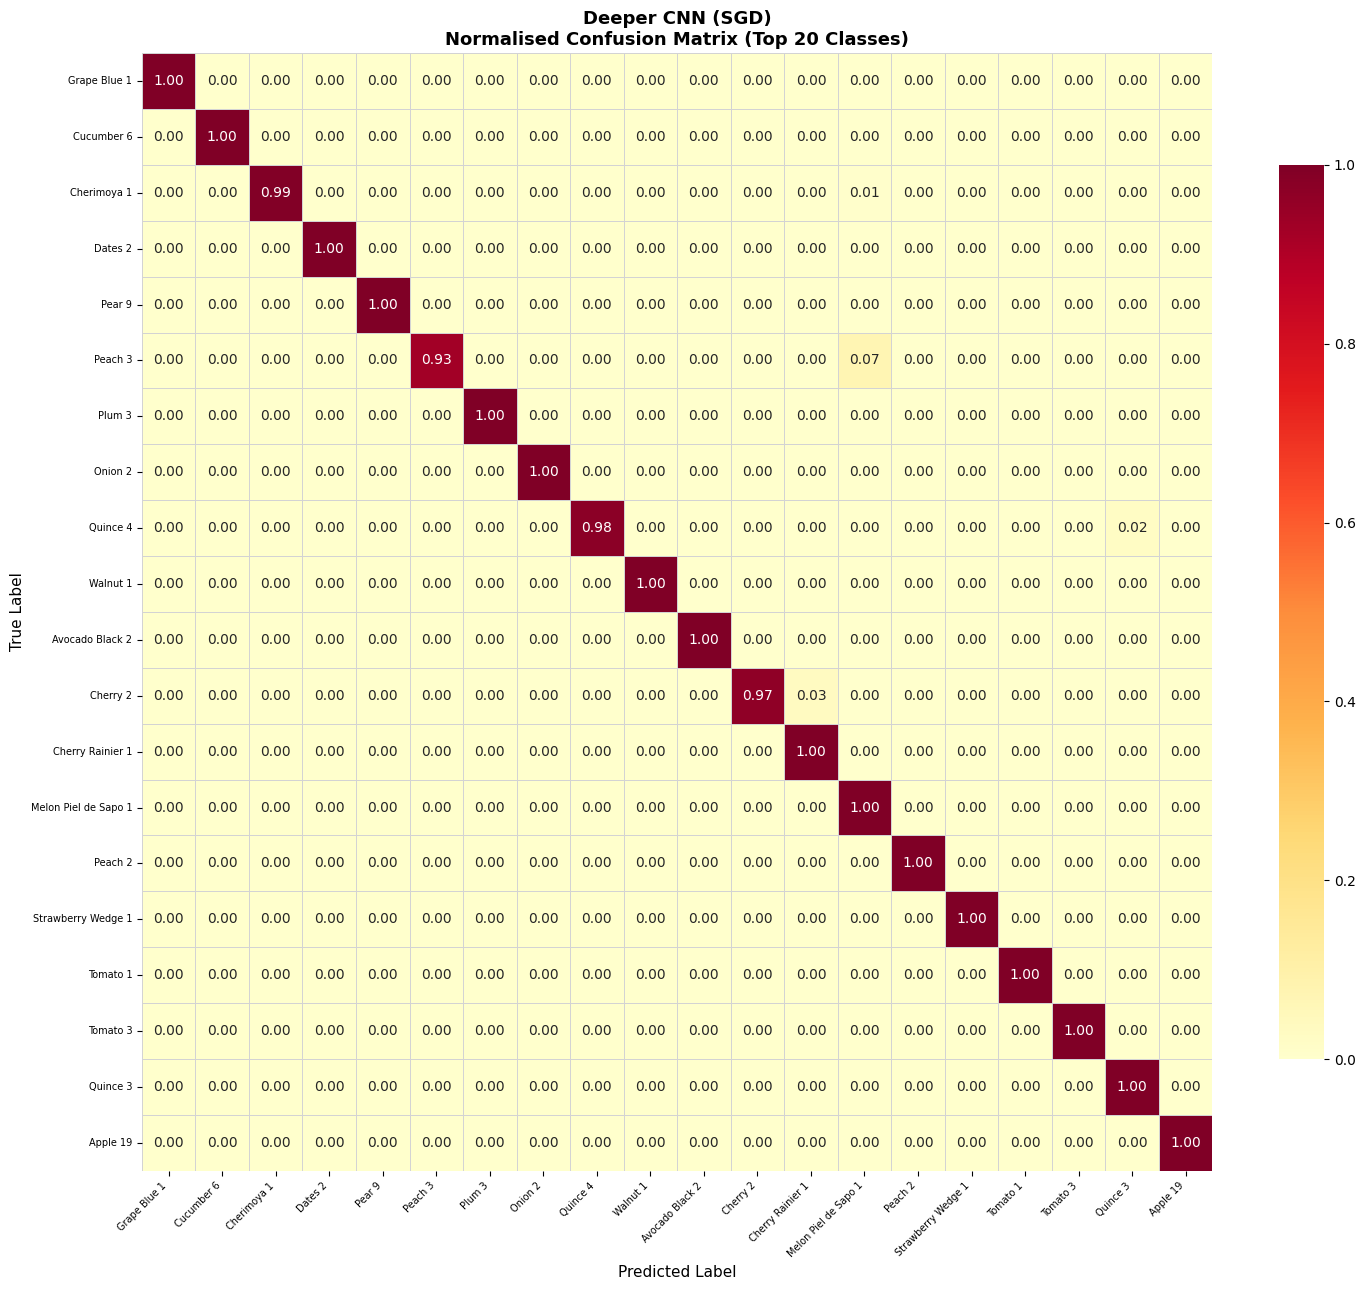

Saved → deeper_adam_inference.png


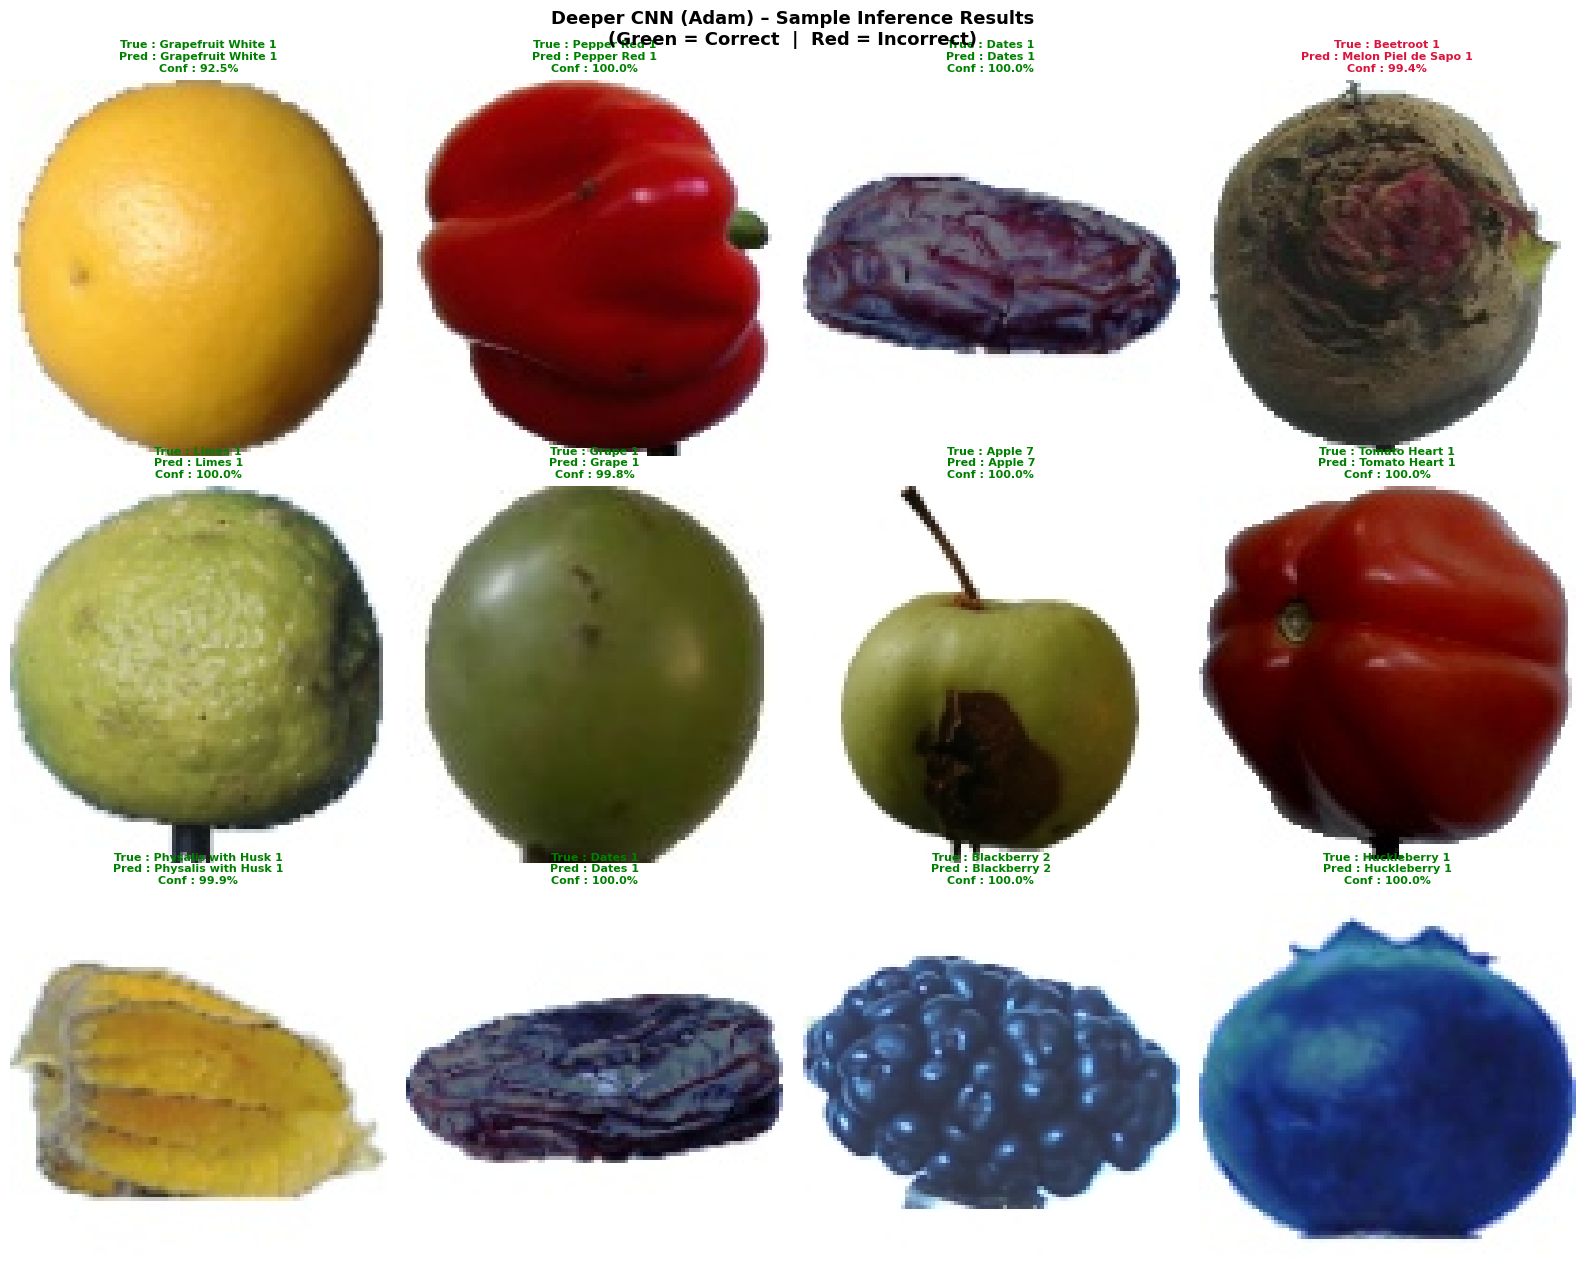

In [25]:
deep_adam_metrics = evaluate_model(deeper_model_adam, test_gen, 'Deeper CNN (Adam)')
deep_sgd_metrics  = evaluate_model(deeper_model_sgd,  test_gen, 'Deeper CNN (SGD)')

# Confusion matrices for both
plot_confusion_matrix_top(deep_adam_metrics['y_true'], deep_adam_metrics['y_pred'],
                      CLASS_LABELS, 'Deeper CNN (Adam)', top_n=20,
                      save='deeper_adam_cm.png')

plot_confusion_matrix_top(deep_sgd_metrics['y_true'], deep_sgd_metrics['y_pred'],
                      CLASS_LABELS, 'Deeper CNN (SGD)', top_n=20,
                      save='deeper_sgd_cm.png')

# Sample inference for deeper (Adam)
show_inference(deeper_model_adam, TEST_DIR, CLASS_LABELS,
                  'Deeper CNN (Adam)', save='deeper_adam_inference.png')


# Optimizer Analysis: SGD vs Adam

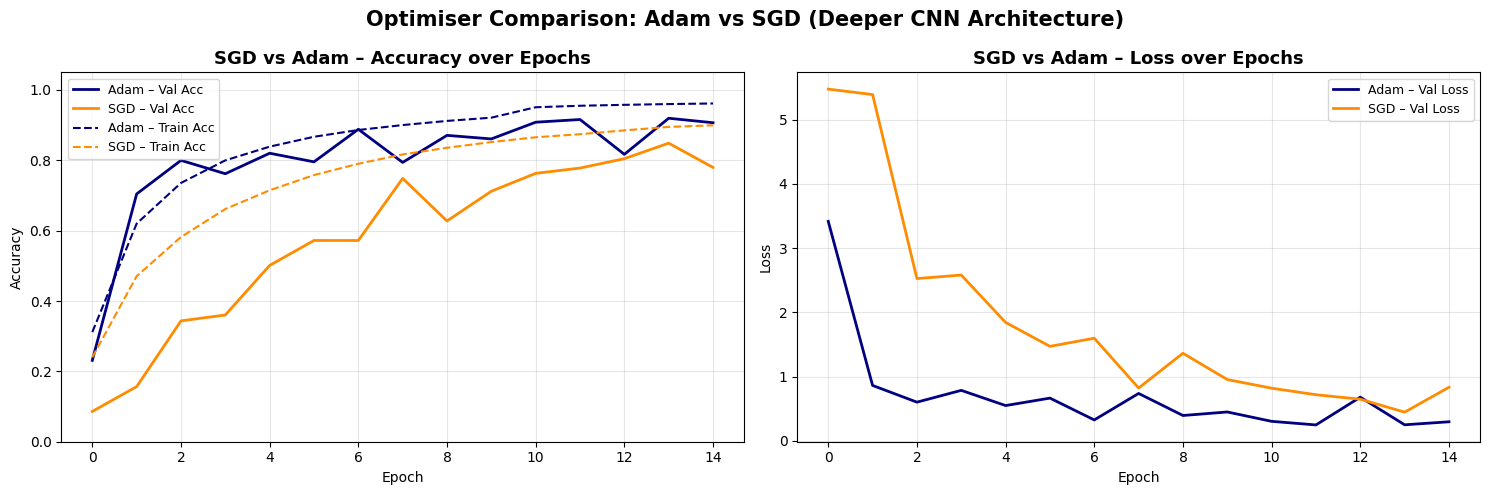

Saved → optimizer_comparison.png

Adam – Best Val Accuracy : 0.9195
SGD  – Best Val Accuracy : 0.8487


In [26]:
fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy curves 
ax_acc.plot(history_deep_adam.history['val_accuracy'], lw=2, color='navy',
            label='Adam – Val Acc')
ax_acc.plot(history_deep_sgd.history['val_accuracy'],  lw=2, color='darkorange',
            label='SGD – Val Acc')
ax_acc.plot(history_deep_adam.history['accuracy'], lw=1.5, color='navy',
            linestyle='--', label='Adam – Train Acc')
ax_acc.plot(history_deep_sgd.history['accuracy'],  lw=1.5, color='darkorange',
            linestyle='--', label='SGD – Train Acc')
ax_acc.set_title('SGD vs Adam – Accuracy over Epochs', fontsize=13, fontweight='bold')
ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Accuracy')
ax_acc.legend(fontsize=9); ax_acc.grid(alpha=0.3); ax_acc.set_ylim(0, 1.05)

#  Loss curves 
ax_loss.plot(history_deep_adam.history['val_loss'], lw=2, color='navy',   label='Adam – Val Loss')
ax_loss.plot(history_deep_sgd.history['val_loss'],  lw=2, color='darkorange', label='SGD – Val Loss')
ax_loss.set_title('SGD vs Adam – Loss over Epochs', fontsize=13, fontweight='bold')
ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
ax_loss.legend(fontsize=9); ax_loss.grid(alpha=0.3)

plt.suptitle('Optimiser Comparison: Adam vs SGD (Deeper CNN Architecture)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → optimizer_comparison.png")

print(f"\nAdam – Best Val Accuracy : {max(history_deep_adam.history['val_accuracy']):.4f}")
print(f"SGD  – Best Val Accuracy : {max(history_deep_sgd.history['val_accuracy']):.4f}")


# PART A – SECTION 4: Ablation Study

# Ablation Study: Remove Dropout

In [28]:
# Ablation: same deeper architecture but ALL Dropout layers removed
def build_ablation_no_dropout(shape, num_classes):
    model = models.Sequential(name='Ablation_NoDrop')

    def conv_bn_nd(filters, pool=True):
        model.add(layers.Conv2D(filters, (3, 3), activation='relu', padding='same'))
        model.add(layers.BatchNormalization())
        if pool:
            model.add(layers.MaxPooling2D((2, 2)))
        # No Dropout

    conv_bn_nd(32,  pool=True)
    conv_bn_nd(64,  pool=True)
    conv_bn_nd(128, pool=True)
    conv_bn_nd(256, pool=False)
    conv_bn_nd(256, pool=True)
    conv_bn_nd(256, pool=False)
    conv_bn_nd(512, pool=False)
    conv_bn_nd(512, pool=True)

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(512, activation='relu'))
    # Dropout intentionally removed
    model.add(layers.Dense(256, activation='relu'))
    # Dropout intentionally removed
    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=Adam(0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


ablation_model = build_ablation_no_dropout(INPUT_SHAPE, NUM_CLASSES)

print(" Training Ablation model (Dropout removed) ...")

t_start = time.time()

history_ablation = ablation_model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=callbacks_deep,
    steps_per_epoch=1000,
    validation_steps=200,
    verbose=1
)

ablation_time = time.time() - t_start

print(f"\n Ablation model trained in {ablation_time / 60:.2f} minutes")

ablation_metrics = evaluate_model(
    ablation_model,
    test_gen,
    'Ablation (No Dropout)'
)

 Training Ablation model (Dropout removed) ...
Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 389s 377ms/step - accuracy: 0.3636 - loss: 2.4263 - val_accuracy: 0.3791 - val_loss: 3.1865 - learning_rate: 0.0010
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 270s 271ms/step - accuracy: 0.7755 - loss: 0.6461 - val_accuracy: 0.6191 - val_loss: 1.4788 - learning_rate: 0.0010
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 365s 365ms/step - accuracy: 0.8482 - loss: 0.4331 - val_accuracy: 0.7691 - val_loss: 0.7335 - learning_rate: 0.0010
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 285s 285ms/step - accuracy: 0.8956 - loss: 0.2895 - val_accuracy: 0.4295 - val_loss: 3.1975 - learning_rate: 0.0010
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 365s 365ms/step - accuracy: 0.9046 - loss: 0.2634 - val_accuracy: 0.8378 - val_loss: 0.5297 - learning_rate: 0.0010
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 271s 271ms/step - accuracy: 0.9254 - loss: 0.2083 - val_accuracy: 0.6308 - val_loss: 1.7818 - learning_rate: 0.0010
Epoch

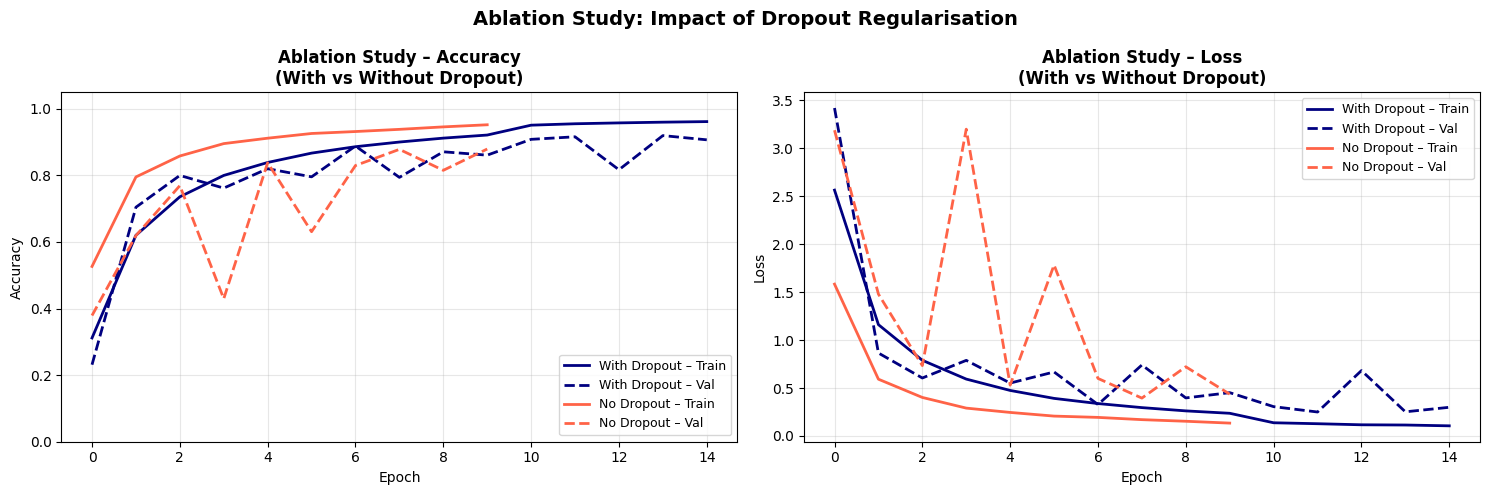

Saved → ablation_study.png


In [29]:
# Ablation Study Visualisation: With Dropout vs Without Dropout 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#  Accuracy comparison 
axes[0].plot(history_deep_adam.history['accuracy'],     lw=2, color='navy',
             label='With Dropout – Train')
axes[0].plot(history_deep_adam.history['val_accuracy'], lw=2, color='navy',
             linestyle='--', label='With Dropout – Val')
axes[0].plot(history_ablation.history['accuracy'],      lw=2, color='tomato',
             label='No Dropout – Train')
axes[0].plot(history_ablation.history['val_accuracy'],  lw=2, color='tomato',
             linestyle='--', label='No Dropout – Val')
axes[0].set_title('Ablation Study – Accuracy\n(With vs Without Dropout)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3); axes[0].set_ylim(0, 1.05)

#  Loss comparison 
axes[1].plot(history_deep_adam.history['loss'],     lw=2, color='navy',
             label='With Dropout – Train')
axes[1].plot(history_deep_adam.history['val_loss'], lw=2, color='navy',
             linestyle='--', label='With Dropout – Val')
axes[1].plot(history_ablation.history['loss'],      lw=2, color='tomato',
             label='No Dropout – Train')
axes[1].plot(history_ablation.history['val_loss'],  lw=2, color='tomato',
             linestyle='--', label='No Dropout – Val')
axes[1].set_title('Ablation Study – Loss\n(With vs Without Dropout)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle('Ablation Study: Impact of Dropout Regularisation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ablation_study.png")


# PART A – SECTION 5: Comparative Analysis

# Baseline vs Deeper Training Curves Side-by-Side

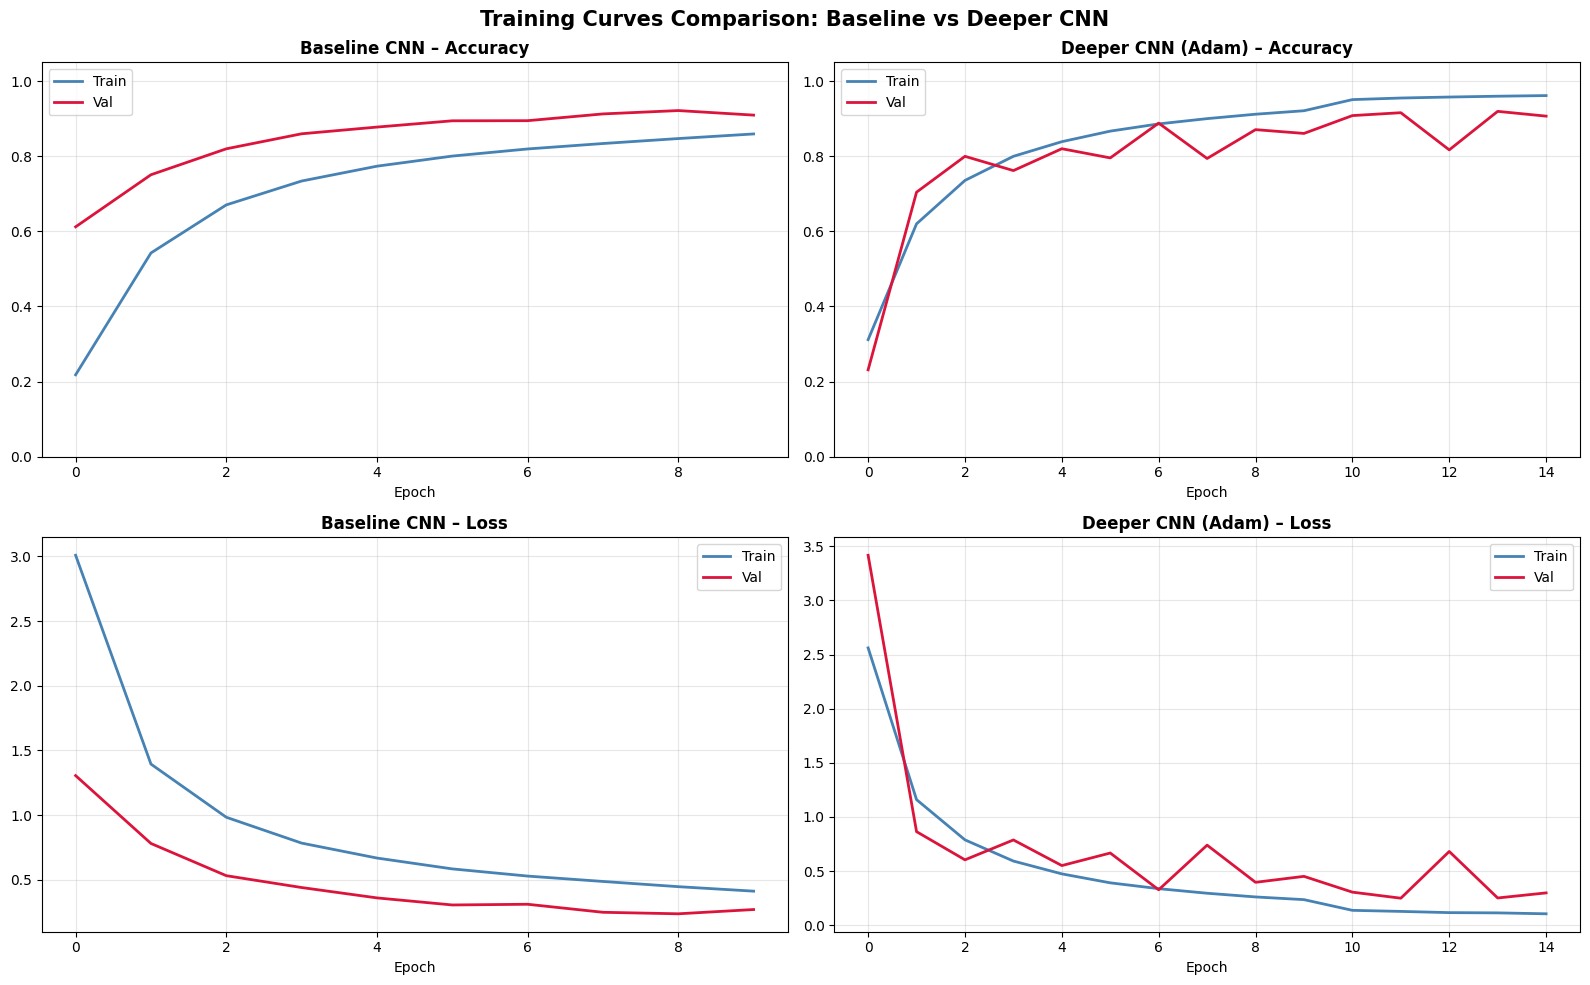

Saved → baseline_vs_deeper_curves.png


In [30]:
# Training Curves Comparison: Baseline CNN vs Deeper CNN 
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

#  Top-left: Baseline Accuracy 
axes[0, 0].plot(history_base.history['accuracy'],     lw=2, color='steelblue', label='Train')
axes[0, 0].plot(history_base.history['val_accuracy'], lw=2, color='crimson',   label='Val')
axes[0, 0].set_title('Baseline CNN – Accuracy', fontweight='bold')
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3); axes[0, 0].set_ylim(0, 1.05)

#  Top-right: Deeper CNN (Adam) Accuracy 
axes[0, 1].plot(history_deep_adam.history['accuracy'],     lw=2, color='steelblue', label='Train')
axes[0, 1].plot(history_deep_adam.history['val_accuracy'], lw=2, color='crimson',   label='Val')
axes[0, 1].set_title('Deeper CNN (Adam) – Accuracy', fontweight='bold')
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3); axes[0, 1].set_ylim(0, 1.05)

#  Bottom-left: Baseline Loss 
axes[1, 0].plot(history_base.history['loss'],     lw=2, color='steelblue', label='Train')
axes[1, 0].plot(history_base.history['val_loss'], lw=2, color='crimson',   label='Val')
axes[1, 0].set_title('Baseline CNN – Loss', fontweight='bold')
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

# Bottom-right: Deeper CNN (Adam) Loss 
axes[1, 1].plot(history_deep_adam.history['loss'],     lw=2, color='steelblue', label='Train')
axes[1, 1].plot(history_deep_adam.history['val_loss'], lw=2, color='crimson',   label='Val')
axes[1, 1].set_title('Deeper CNN (Adam) – Loss', fontweight='bold')
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

for ax in axes.ravel():
    ax.set_xlabel('Epoch')

plt.suptitle('Training Curves Comparison: Baseline vs Deeper CNN',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_vs_deeper_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → baseline_vs_deeper_curves.png")


# Comprehensive Model Comparison

 PART A – COMPREHENSIVE MODEL COMPARISON
                Model  Conv Layers Regularisation Optimiser Accuracy Precision Recall F1-Score  Train Time (min)
         Baseline CNN            3        Dropout      Adam   0.9321    0.9374 0.9321   0.9265            100.30
    Deeper CNN (Adam)            8   BN + Dropout      Adam   0.9535    0.9604 0.9535   0.9521            142.12
     Deeper CNN (SGD)            8   BN + Dropout       SGD   0.8999    0.9092 0.8999   0.8950             75.06
Ablation (No Dropout)            8 BatchNorm only      Adam   0.8593    0.8925 0.8593   0.8543             53.89


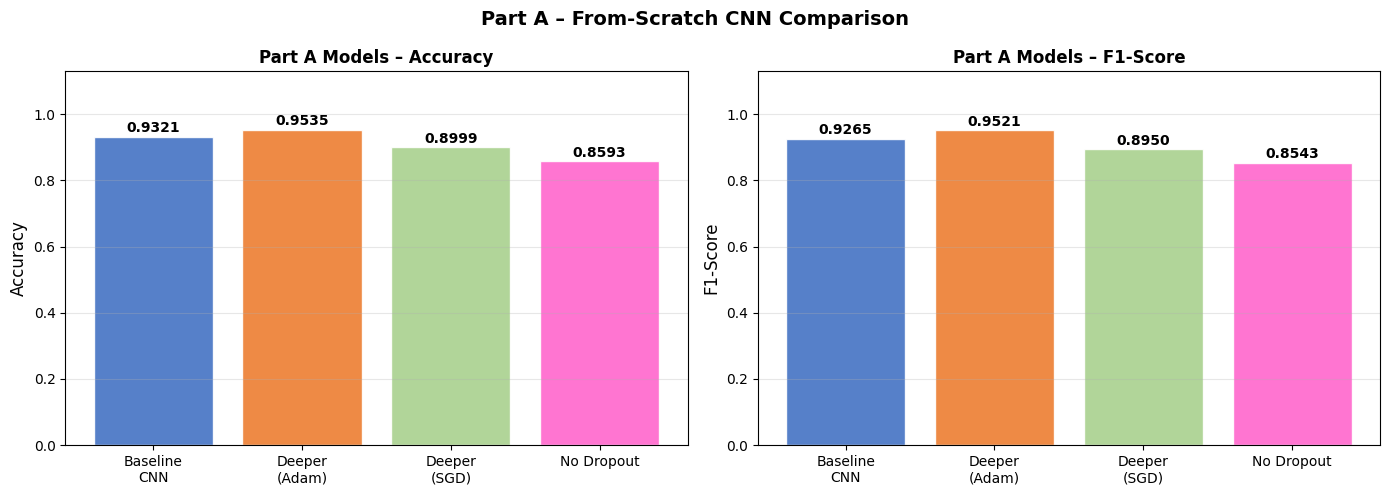

Saved → part_a_comparison.png


In [31]:
comparison_data = {
    'Model'            : ['Baseline CNN', 'Deeper CNN (Adam)', 'Deeper CNN (SGD)', 'Ablation (No Dropout)'],
    'Conv Layers'      : [3, 8, 8, 8],
    'Regularisation'   : ['Dropout', 'BN + Dropout', 'BN + Dropout', 'BatchNorm only'],
    'Optimiser'        : ['Adam', 'Adam', 'SGD', 'Adam'],
    'Accuracy'         : [base_metrics['acc'], deep_adam_metrics['acc'],
                          deep_sgd_metrics['acc'], ablation_metrics['acc']],
    'Precision'        : [base_metrics['prec'], deep_adam_metrics['prec'],
                          deep_sgd_metrics['prec'], ablation_metrics['prec']],
    'Recall'           : [base_metrics['rec'], deep_adam_metrics['rec'],
                          deep_sgd_metrics['rec'], ablation_metrics['rec']],
    'F1-Score'         : [base_metrics['f1'], deep_adam_metrics['f1'],
                          deep_sgd_metrics['f1'], ablation_metrics['f1']],
    'Train Time (min)' : [round(base_train_time/60, 2), round(deep_adam_time/60, 2),
                          round(deep_sgd_time/60, 2), round(ablation_time/60, 2)]
}

comp_df = pd.DataFrame(comparison_data)
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    comp_df[col] = comp_df[col].apply(lambda v: f'{v:.4f}')

print("=" * 100)
print(" PART A – COMPREHENSIVE MODEL COMPARISON")
print("=" * 100)
print(comp_df.to_string(index=False))

# Bar chart 
model_names = ['Baseline\nCNN', 'Deeper\n(Adam)', 'Deeper\n(SGD)', 'No Dropout']
accs  = [base_metrics['acc'], deep_adam_metrics['acc'], deep_sgd_metrics['acc'], ablation_metrics['acc']]
f1s   = [base_metrics['f1'],  deep_adam_metrics['f1'],  deep_sgd_metrics['f1'],  ablation_metrics['f1']]
clrs  = ['#4472C4', '#ED7D31', '#A9D18E', '#FF66CC']

fig, (bax1, bax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax, vals, metric in [(bax1, accs, 'Accuracy'), (bax2, f1s, 'F1-Score')]:
    bars = ax.bar(model_names, vals, color=clrs, edgecolor='white', alpha=0.9)
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.004,
                f'{b.get_height():.4f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'Part A Models – {metric}', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.13); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Part A – From-Scratch CNN Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('part_a_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → part_a_comparison.png")


# PART B: Transfer Learning with MobileNetV2

# Transfer Learning Data Generators (96×96)

In [32]:
# MobileNetV2 minimum input: 96×96
TL_IMG_SIZE = (96, 96)

tl_train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=25,
    width_shift_range=0.12, height_shift_range=0.12,
    shear_range=0.08, zoom_range=0.18,
    horizontal_flip=True, validation_split=VAL_SPLIT
)
tl_test_datagen = ImageDataGenerator(rescale=1./255)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_IMG_SIZE, batch_size=32,
    class_mode='categorical', subset='training', seed=SEED
)
tl_val_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_IMG_SIZE, batch_size=32,
    class_mode='categorical', subset='validation', seed=SEED
)
tl_test_gen = tl_test_datagen.flow_from_directory(
    TEST_DIR, target_size=TL_IMG_SIZE, batch_size=32,
    class_mode='categorical', shuffle=False
)

print(f"TL Train samples : {tl_train_gen.samples:,}")
print(f"TL Val samples   : {tl_val_gen.samples:,}")
print(f"TL Test samples  : {tl_test_gen.samples:,}")
print(f"TL Input size    : {TL_IMG_SIZE[0]}×{TL_IMG_SIZE[1]}×3")


Found 108338 images belonging to 258 classes.
Found 26975 images belonging to 258 classes.
Found 45088 images belonging to 258 classes.
TL Train samples : 108,338
TL Val samples   : 26,975
TL Test samples  : 45,088
TL Input size    : 96×96×3


# Load MobileNetV2 & Build Transfer Learning Model

In [33]:
#  Load MobileNetV2 pre-trained on ImageNet 
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(TL_IMG_SIZE[0], TL_IMG_SIZE[1], 3)
)
base_model.trainable = False  # Phase 1: freeze all base_model weights

print(f"MobileNetV2 base_model layers   : {len(base_model.layers)}")
trainable_params = sum(tf.size(w).numpy() for w in base_model.trainable_weights)
print(f"Backbone trainable params     : {trainable_params} (should be 0 when frozen)")

#  Build functional model 
inputs = keras.Input(shape=(TL_IMG_SIZE[0], TL_IMG_SIZE[1], 3), name='input_layer')
x   = base_model(inputs, training=False)
x   = layers.GlobalAveragePooling2D(name='gap')(x)
x   = layers.Dense(256, activation='relu', name='tl_fc1')(x)
x   = layers.Dropout(0.45, name='tl_drop1')(x)
x   = layers.Dense(128, activation='relu', name='tl_fc2')(x)
x   = layers.Dropout(0.35, name='tl_drop2')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='tl_output')(x)

tl_model = keras.Model(inputs, outputs, name='MobileNetV2_TL')
tl_model.compile(optimizer=Adam(0.001),
               loss='categorical_crossentropy', metrics=['accuracy'])
tl_model.summary()

total_p     = tl_model.count_params()
trainable_p = sum(tf.size(w).numpy() for w in tl_model.trainable_weights)
print(f"\nTotal params        : {total_p:,}")
print(f"Trainable params    : {trainable_p:,} (Dense head only)")
print(f"Non-trainable params: {total_p - trainable_p:,} (frozen base_model)")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 base_model layers   : 154
Backbone trainable params     : 0 (should be 0 when frozen)


Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tl_fc1 (Dense)                  │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tl_drop1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tl_fc2 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tl_drop2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tl_output (Dense)               │ (None, 258)            │        33,282 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,652,098 (10.12 MB)

 Trainable params: 394,114 (1.50 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Total params        : 2,652,098
Trainable params    : 394,114 (Dense head only)
Non-trainable params: 2,257,984 (frozen base_model)


# Phase 1: Feature Extraction Training

In [37]:
tl_callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("PHASE 1 – Feature Extraction (MobileNetV2 base_model frozen)")
print("Training only the Dense classification head ...")
t_start = time.time()

history_tl_phase1 = tl_model.fit(
    tl_train_gen,
    epochs=5,
    validation_data=tl_val_gen,
    callbacks=tl_callbacks,
    steps_per_epoch=1000,
    validation_steps=200,
    verbose=1
)

tl_phase1_time = time.time() - t_start
print(f"\n✔ Phase 1 completed in {tl_phase1_time / 60:.2f} minutes")
print(f"  Best Phase 1 val accuracy: {max(history_tl_phase1.history['val_accuracy']):.4f}")

PHASE 1 – Feature Extraction (MobileNetV2 base_model frozen)
Training only the Dense classification head ...
Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 181s 181ms/step - accuracy: 0.6078 - loss: 1.2888 - val_accuracy: 0.8083 - val_loss: 0.6143 - learning_rate: 0.0010
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 176s 176ms/step - accuracy: 0.6474 - loss: 1.1370 - val_accuracy: 0.8208 - val_loss: 0.5536 - learning_rate: 0.0010
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 179s 179ms/step - accuracy: 0.6700 - loss: 1.0611 - val_accuracy: 0.8311 - val_loss: 0.5506 - learning_rate: 0.0010
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 84s 84ms/step - accuracy: 0.6911 - loss: 0.9823 - val_accuracy: 0.8483 - val_loss: 0.4713 - learning_rate: 0.0010
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 180s 180ms/step - accuracy: 0.6957 - loss: 0.9796 - val_accuracy: 0.8489 - val_loss: 0.4767 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.

✔ Phase 1 completed in 13.33 minutes
  Best Phas

# Phase 2: Fine-Tuning (Unfreeze Top Layers)

In [49]:
print("PHASE 2 – Fine-Tuning (unfreezing top 30 MobileNetV2 layers)")

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with much lower learning rate to avoid catastrophic forgetting
tl_model.compile(
    optimizer=Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable_ph2 = sum(tf.size(w).numpy() for w in tl_model.trainable_weights)
print(f"Phase 2 trainable params: {trainable_ph2:,} (top 30 layers + head)")

t_start = time.time()

history_tl_phase2 = tl_model.fit(
    tl_train_gen,
    epochs=EPOCHS_TL,
    validation_data=tl_val_gen,
    callbacks=tl_callbacks,
    steps_per_epoch=1000,
    validation_steps=200,
    verbose=1
)

tl_phase2_time = time.time() - t_start
tl_total_time = tl_phase1_time + tl_phase2_time

print(f"\n✔ Phase 2 completed in {tl_phase2_time / 60:.2f} minutes")
print(f"  Total TL training time : {tl_total_time / 60:.2f} minutes")

PHASE 2 – Fine-Tuning (unfreezing top 30 MobileNetV2 layers)
Phase 2 trainable params: 1,920,514 (top 30 layers + head)
Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 206s 190ms/step - accuracy: 0.7221 - loss: 0.8951 - val_accuracy: 0.9008 - val_loss: 0.3228 - learning_rate: 1.0000e-05
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 193s 194ms/step - accuracy: 0.7314 - loss: 0.8584 - val_accuracy: 0.9016 - val_loss: 0.3047 - learning_rate: 1.0000e-05
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 178s 178ms/step - accuracy: 0.7424 - loss: 0.8038 - val_accuracy: 0.9052 - val_loss: 0.2944 - learning_rate: 1.0000e-05
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 83s 83ms/step - accuracy: 0.7502 - loss: 0.7876 - val_accuracy: 0.9034 - val_loss: 0.3048 - learning_rate: 1.0000e-05
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 185s 185ms/step - accuracy: 0.7541 - loss: 0.7766 - val_accuracy: 0.9150 - val_loss: 0.2690 - learning_rate: 1.0000e-05
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 184s 184ms/step - accuracy: 0.

# Plot Transfer Learning Training Curves

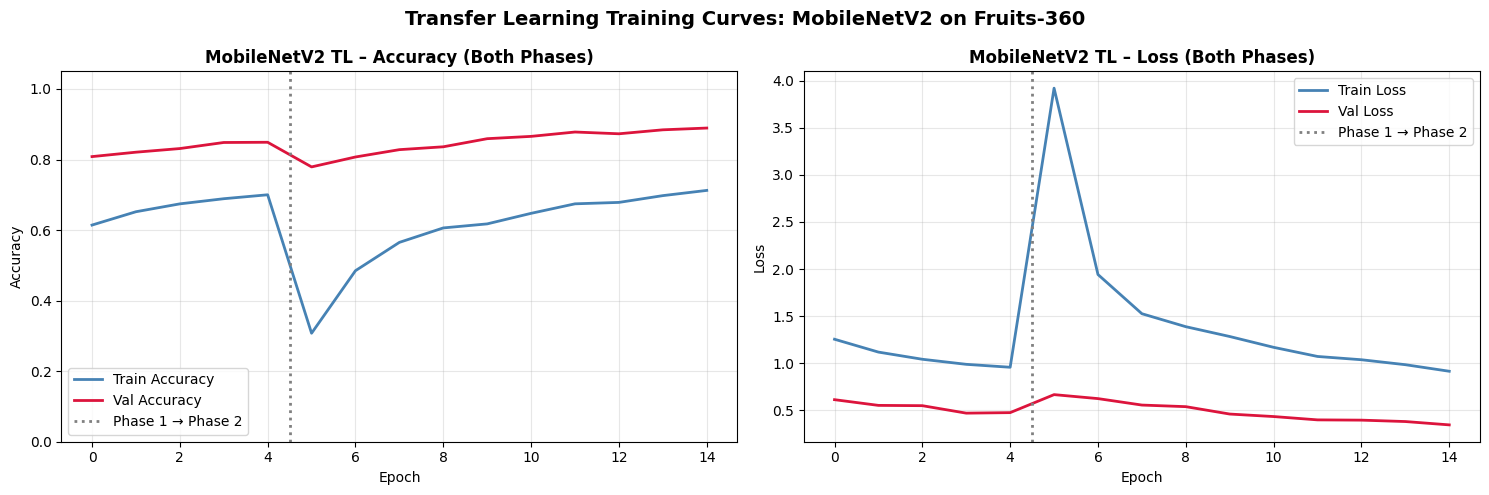

Saved → tl_training_curves.png


In [39]:
# Concatenate Phase 1 + Phase 2 histories 
acc_all     = history_tl_phase1.history['accuracy']     + history_tl_phase2.history['accuracy']
val_acc_all = history_tl_phase1.history['val_accuracy'] + history_tl_phase2.history['val_accuracy']
loss_all    = history_tl_phase1.history['loss']         + history_tl_phase2.history['loss']
val_loss_all = history_tl_phase1.history['val_loss']     + history_tl_phase2.history['val_loss']

phase1_end = len(history_tl_phase1.history['accuracy'])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5))

a1.plot(acc_all,     lw=2, color='steelblue', label='Train Accuracy')
a1.plot(val_acc_all, lw=2, color='crimson',   label='Val Accuracy')
a1.axvline(phase1_end - 0.5, color='gray', linestyle=':', lw=2,
           label='Phase 1 → Phase 2')
a1.set_title('MobileNetV2 TL – Accuracy (Both Phases)', fontweight='bold')
a1.set_xlabel('Epoch'); a1.set_ylabel('Accuracy')
a1.legend(); a1.grid(alpha=0.3); a1.set_ylim(0, 1.05)

a2.plot(loss_all,    lw=2, color='steelblue', label='Train Loss')
a2.plot(val_loss_all, lw=2, color='crimson',   label='Val Loss')
a2.axvline(phase1_end - 0.5, color='gray', linestyle=':', lw=2,
           label='Phase 1 → Phase 2')
a2.set_title('MobileNetV2 TL – Loss (Both Phases)', fontweight='bold')
a2.set_xlabel('Epoch'); a2.set_ylabel('Loss')
a2.legend(); a2.grid(alpha=0.3)

plt.suptitle('Transfer Learning Training Curves: MobileNetV2 on Fruits-360',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tl_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → tl_training_curves.png")


# Evaluate Transfer Learning Model

1409/1409 ━━━━━━━━━━━━━━━━━━━━ 107s 76ms/step

  MobileNetV2 (Transfer Learning)
  Accuracy  : 0.8665  (86.65 %)
  Precision : 0.8865  (weighted)
  Recall    : 0.8665  (weighted)
  F1-Score  : 0.8641  (weighted)
Saved → tl_cm.png


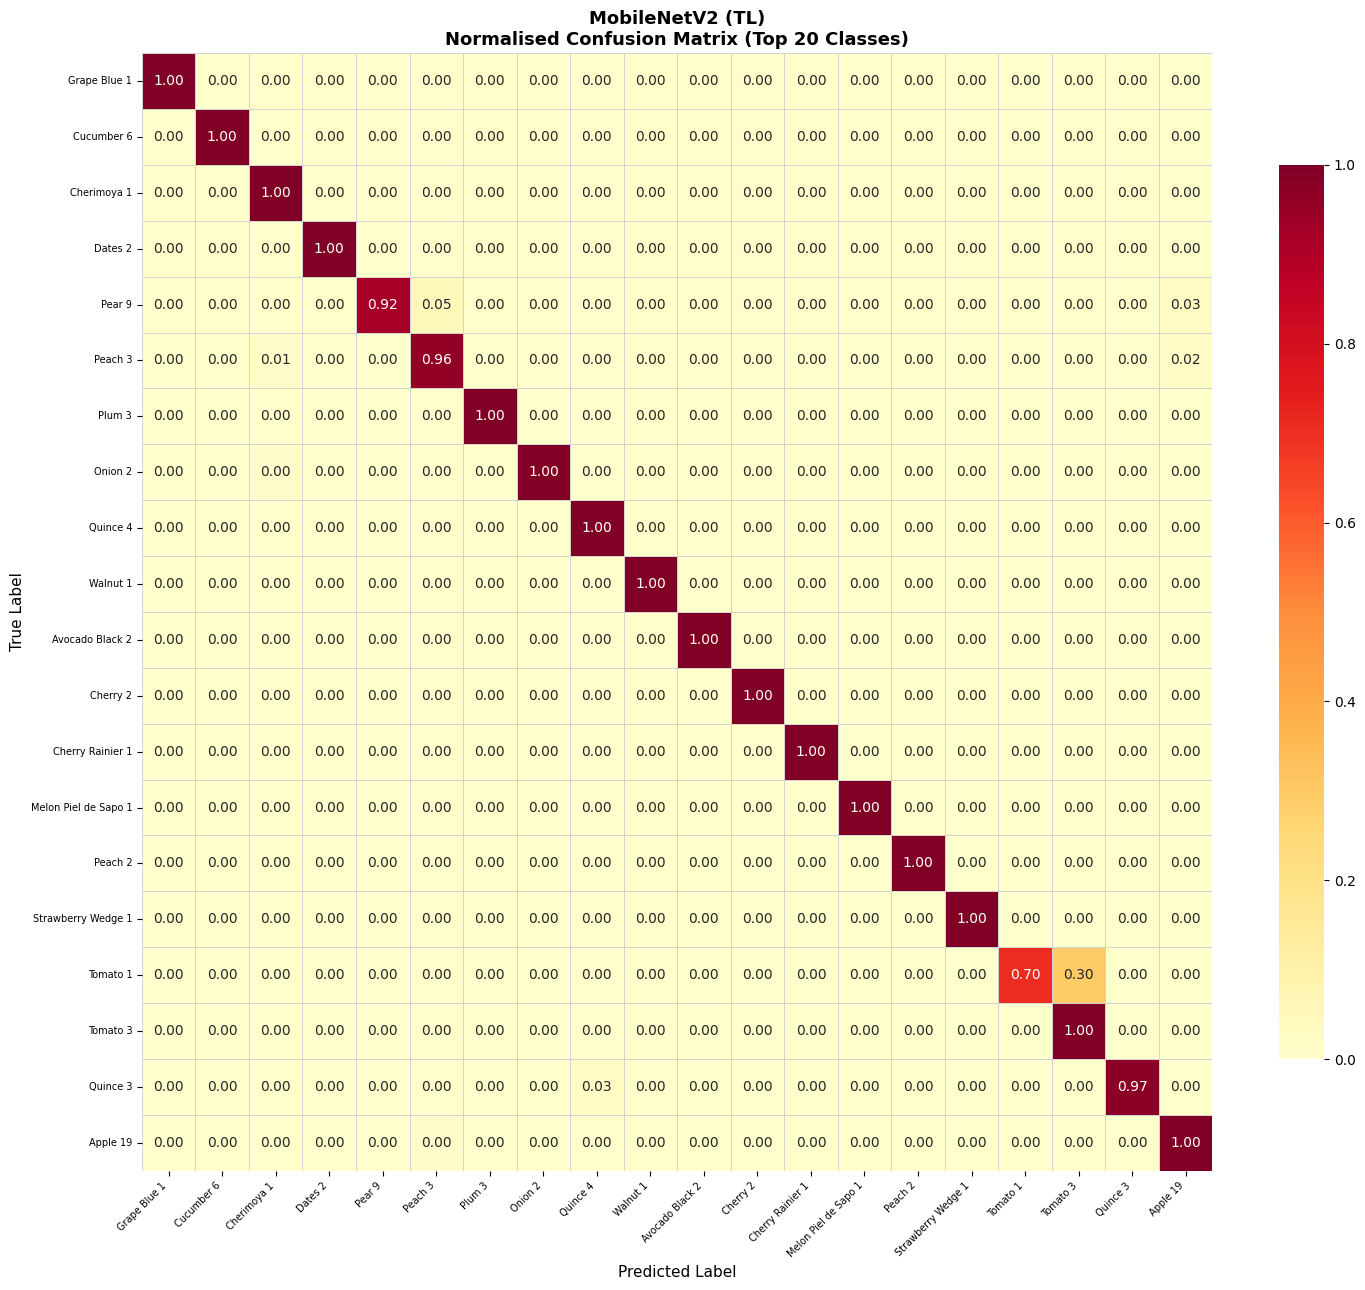

Saved → tl_inference.png


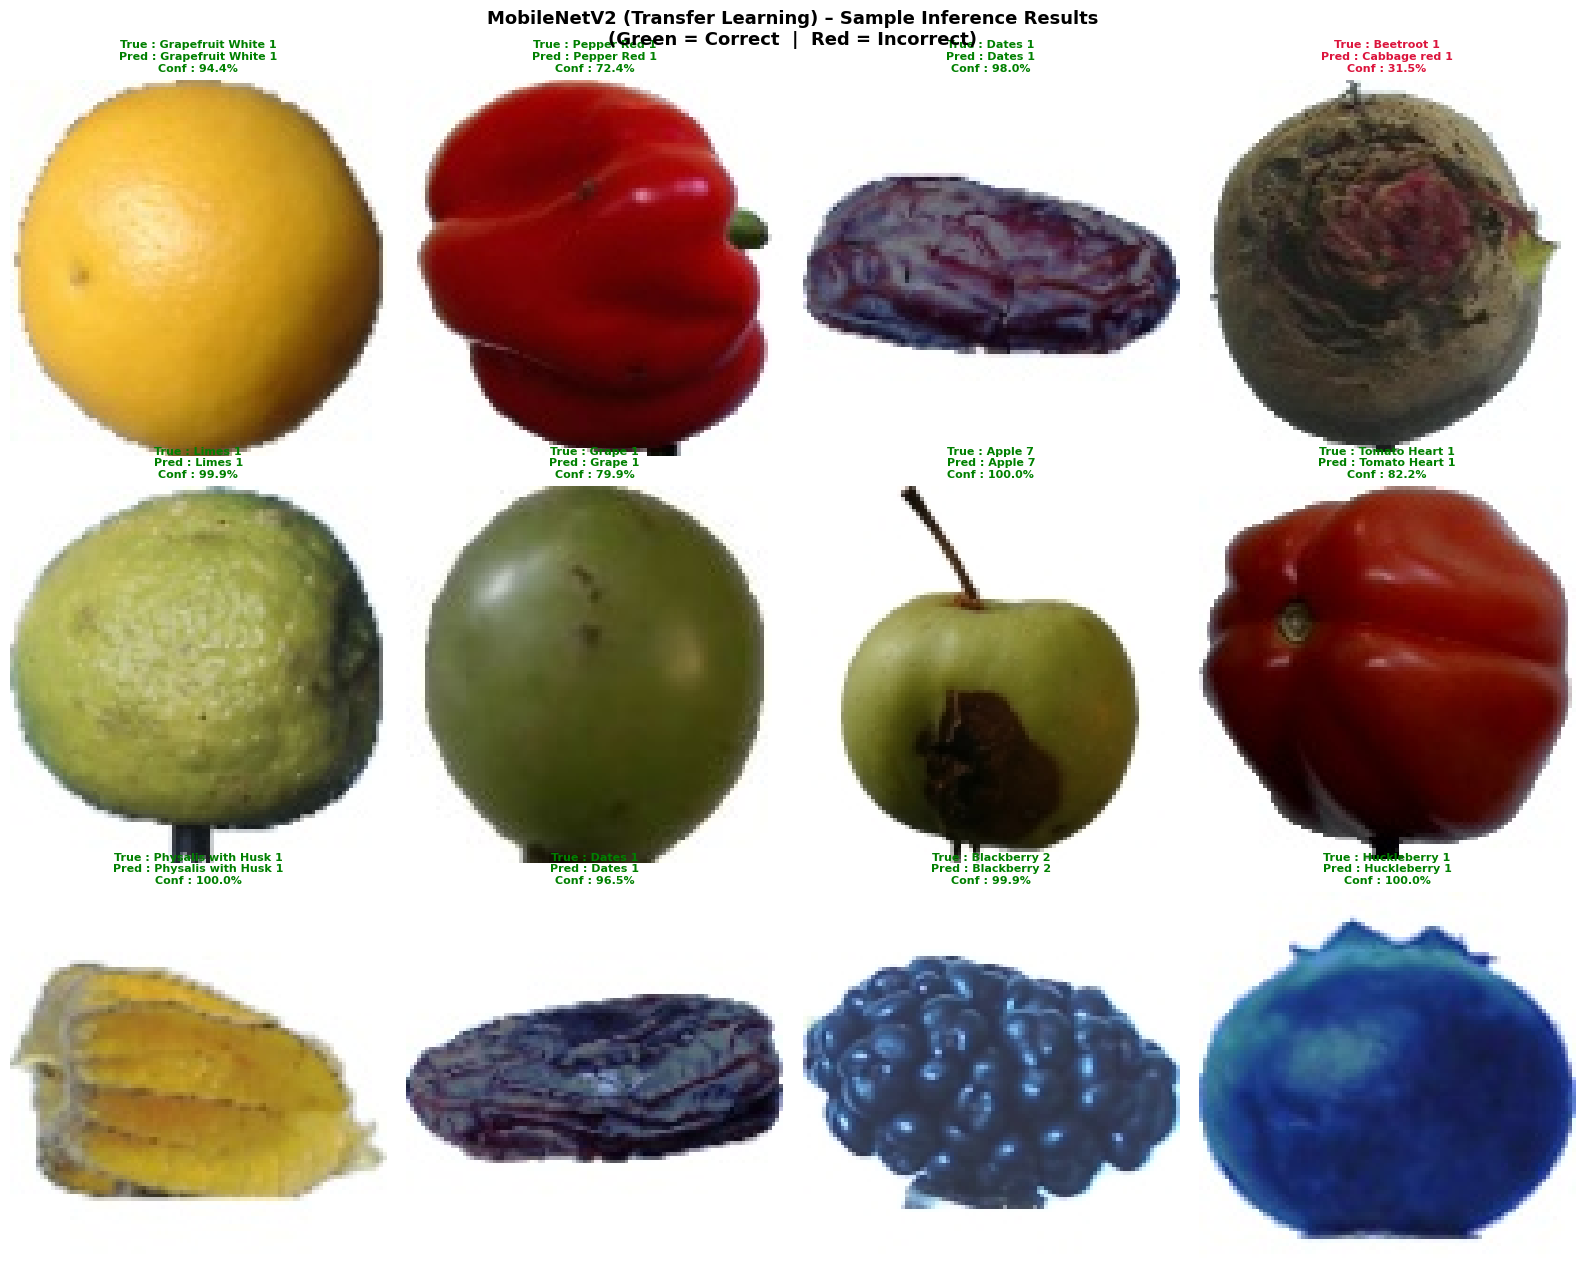


Full Classification Report – MobileNetV2:
                        precision    recall  f1-score   support

             Almonds 1       0.97      0.97      0.97        77
              Apple 10       0.85      0.53      0.65       231
              Apple 11       0.90      0.79      0.84       142
              Apple 12       0.96      0.71      0.82       154
              Apple 13       0.81      1.00      0.90       235
              Apple 14       0.90      0.86      0.88       154
              Apple 17       0.73      0.88      0.80       201
              Apple 18       0.71      0.86      0.78       240
              Apple 19       0.85      1.00      0.92       241
              Apple 20       0.99      0.93      0.96       234
              Apple 21       0.96      0.92      0.94       162
              Apple 22       0.95      0.75      0.84       231
              Apple 23       1.00      0.99      1.00       156
               Apple 5       0.53      1.00      0.70       

In [48]:
tl_metrics = evaluate_model(tl_model, tl_test_gen, 'MobileNetV2 (Transfer Learning)')

plot_confusion_matrix_top(tl_metrics['y_true'], tl_metrics['y_pred'],
                      CLASS_LABELS, 'MobileNetV2 (TL)',
                      top_n=20, save='tl_cm.png')

# Wrap tl_model so it resizes to 96×96 before inference on 100×100 images
inference_model = tf.keras.Sequential([
    tf.keras.layers.Resizing(TL_IMG_SIZE[0], TL_IMG_SIZE[1]),
    tl_model
])
show_inference(inference_model, TEST_DIR, CLASS_LABELS,
                  'MobileNetV2 (Transfer Learning)', save='tl_inference.png')

print("\nFull Classification Report – MobileNetV2:")
print(classification_report(tl_metrics['y_true'], tl_metrics['y_pred'],
                             target_names=CLASS_LABELS, zero_division=0))


# Final Comparison: All Models (Part A + Part B)

  FINAL COMPARISON – ALL MODELS (Part A + Part B)
                Model Part       Conv Layers Accuracy F1-Score  Train Time (min)
         Baseline CNN    A                 3   0.9321   0.9265            100.30
    Deeper CNN (Adam)    A                 8   0.9535   0.9521            142.12
     Deeper CNN (SGD)    A                 8   0.8999   0.8950             75.06
Ablation (No Dropout)    A                 8   0.8593   0.8543             53.89
     MobileNetV2 (TL)    B 53 (frozen+top30)   0.8665   0.8641             41.11


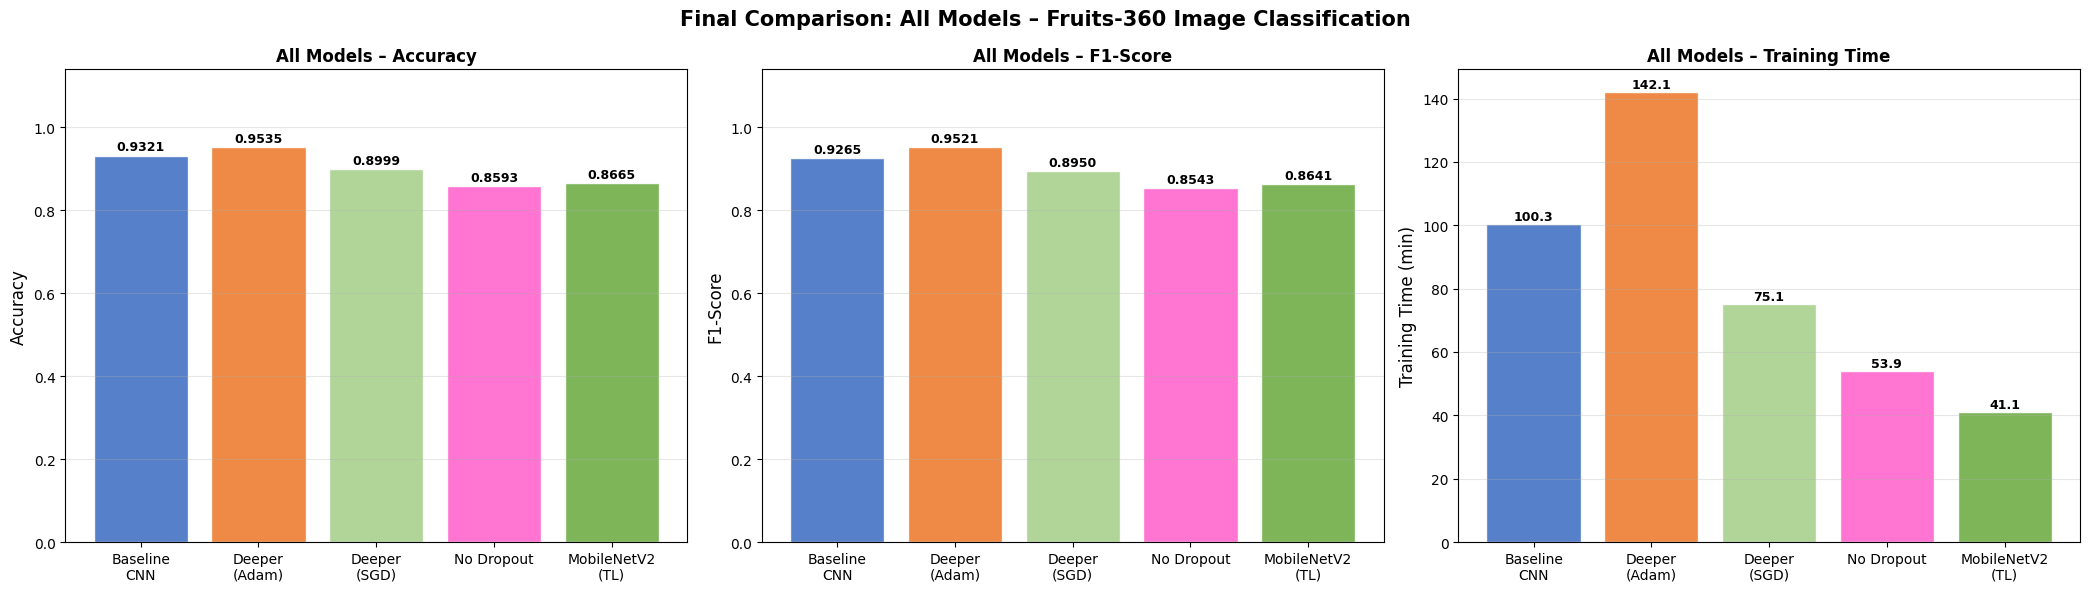

Saved → final_comparison.png


In [45]:
final_data = {
    'Model'           : ['Baseline CNN', 'Deeper CNN (Adam)', 'Deeper CNN (SGD)',
                         'Ablation (No Dropout)', 'MobileNetV2 (TL)'],
    'Part'            : ['A', 'A', 'A', 'A', 'B'],
    'Conv Layers'     : [3, 8, 8, 8, '53 (frozen+top30)'],
    'Accuracy'        : [base_metrics['acc'], deep_adam_metrics['acc'], deep_sgd_metrics['acc'],
                         ablation_metrics['acc'], tl_metrics['acc']],
    'F1-Score'        : [base_metrics['f1'],  deep_adam_metrics['f1'],  deep_sgd_metrics['f1'],
                         ablation_metrics['f1'],  tl_metrics['f1']],
    'Train Time (min)': [round(base_train_time/60, 2), round(deep_adam_time/60, 2),
                         round(deep_sgd_time/60, 2), round(ablation_time/60, 2),
                         round(tl_total_time/60, 2)]
}

final_df = pd.DataFrame(final_data)
for col in ['Accuracy', 'F1-Score']:
    final_df[col] = final_df[col].apply(lambda v: f'{v:.4f}' if isinstance(v, float) else v)

print("=" * 90)
print("  FINAL COMPARISON – ALL MODELS (Part A + Part B)")
print("=" * 90)
print(final_df.to_string(index=False))

#  Final bar charts 
model_short = ['Baseline\nCNN', 'Deeper\n(Adam)', 'Deeper\n(SGD)',
            'No Dropout', 'MobileNetV2\n(TL)']
accs_all  = [base_metrics['acc'], deep_adam_metrics['acc'], deep_sgd_metrics['acc'],
           ablation_metrics['acc'], tl_metrics['acc']]
f1s_all  = [base_metrics['f1'],  deep_adam_metrics['f1'],  deep_sgd_metrics['f1'],
           ablation_metrics['f1'],  tl_metrics['f1']]
times_all  = [base_train_time/60, deep_adam_time/60, deep_sgd_time/60,
           ablation_time/60, tl_total_time/60]

clrs = ['#4472C4', '#ED7D31', '#A9D18E', '#FF66CC', '#70AD47']

fig, (fax1, fax2, fax3) = plt.subplots(1, 3, figsize=(21, 6))

for ax, vals, metric in [(fax1, accs_all, 'Accuracy'), (fax2, f1s_all, 'F1-Score')]:
    brs = ax.bar(model_short, vals, color=clrs, edgecolor='white', alpha=0.9)
    for b in brs:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f'{b.get_height():.4f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'All Models – {metric}', fontweight='bold')
    ax.set_ylim(0, 1.14); ax.grid(axis='y', alpha=0.3)

brs3 = fax3.bar(model_short, times_all, color=clrs, edgecolor='white', alpha=0.9)
for b in brs3:
    fax3.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
              f'{b.get_height():.1f}', ha='center', va='bottom',
              fontsize=9, fontweight='bold')
fax3.set_ylabel('Training Time (min)', fontsize=12)
fax3.set_title('All Models – Training Time', fontweight='bold')
fax3.grid(axis='y', alpha=0.3)

plt.suptitle('Final Comparison: All Models – Fruits-360 Image Classification',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → final_comparison.png")


# Runtime Summary & Hardware Report

In [46]:
total_runtime = base_train_time + deep_adam_time + deep_sgd_time + ablation_time + tl_total_time

print("=" * 60)
print("  RUNTIME & HARDWARE SUMMARY")
print("=" * 60)
print(f"  Platform              : Kaggle Notebook")
print(f"  GPU devices           : {tf.config.list_physical_devices('GPU')}")
print(f"  TensorFlow version    : {tf.__version__}")
print(f"  Dataset               : Fruits-360 (100×100 RGB)")
print(f"  Classes               : {NUM_CLASSES}")
print(f"  Training images       : {train_gen.samples:,}")
print(f"  Validation images     : {val_gen.samples:,}")
print(f"  Test images           : {test_gen.samples:,}")
print(f"  -" * 30)
print(f"  Baseline CNN          : {base_train_time/60:.2f} min  ({EPOCHS_BASE} epochs, Adam)")
print(f"  Deeper CNN (Adam)     : {deep_adam_time/60:.2f} min  ({EPOCHS_DEEP} epochs, Adam)")
print(f"  Deeper CNN (SGD)      : {deep_sgd_time/60:.2f} min  ({EPOCHS_DEEP} epochs, SGD)")
print(f"  Ablation (No Dropout) : {ablation_time/60:.2f} min  (10 epochs, Adam)")
print(f"  MobileNetV2 Phase 1   : {tl_phase1_time/60:.2f} min  (5 epochs, frozen)")
print(f"  MobileNetV2 Phase 2   : {tl_phase2_time/60:.2f} min  ({EPOCHS_TL} epochs, fine-tune)")
print(f"  TOTAL RUNTIME         : {total_runtime/60:.2f} minutes")


  RUNTIME & HARDWARE SUMMARY
  Platform              : Kaggle Notebook
  GPU devices           : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
  TensorFlow version    : 2.19.0
  Dataset               : Fruits-360 (100×100 RGB)
  Classes               : 258
  Training images       : 108,338
  Validation images     : 26,975
  Test images           : 45,088
  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -
  Baseline CNN          : 100.30 min  (10 epochs, Adam)
  Deeper CNN (Adam)     : 142.12 min  (15 epochs, Adam)
  Deeper CNN (SGD)      : 75.06 min  (15 epochs, SGD)
  Ablation (No Dropout) : 53.89 min  (10 epochs, Adam)
  MobileNetV2 Phase 1   : 13.33 min  (5 epochs, frozen)
  MobileNetV2 Phase 2   : 27.77 min  (10 epochs, fine-tune)
  TOTAL RUNTIME         : 412.48 minutes


# Save All Models

In [47]:
baseline_model.save('baseline_cnn.keras')
deeper_model_adam.save('deeper_cnn_adam.keras')
deeper_model_sgd.save('deeper_cnn_sgd.keras')
tl_model.save('mobilenetv2_tl.keras')

print("✔ All models saved.")
print("\nOutput artefacts:")
for fname in sorted(os.listdir('.')):
    if fname.endswith(('.keras', '.png')):
        sz = os.path.getsize(fname) / (1024 * 1024)
        print(f"  {fname:<45} {sz:.2f} MB")


✔ All models saved.

Output artefacts:
  ablation_study.png                            0.17 MB
  augmentation_examples.png                     0.30 MB
  baseline_cm.png                               0.19 MB
  baseline_cnn.keras                            55.79 MB
  baseline_inference.png                        0.38 MB
  baseline_training_curves.png                  0.07 MB
  baseline_vs_deeper_curves.png                 0.18 MB
  class_distribution.png                        0.16 MB
  deeper_adam_cm.png                            0.19 MB
  deeper_adam_inference.png                     0.39 MB
  deeper_cnn_adam.keras                         63.93 MB
  deeper_cnn_sgd.keras                          42.66 MB
  deeper_sgd_cm.png                             0.20 MB
  final_comparison.png                          0.10 MB
  mobilenetv2_tl.keras                          25.36 MB
  optimizer_comparison.png                      0.15 MB
  part_a_comparison.png                         0.06 MB
  pix